# **R : Experiment - 8**

Mayuresh Vengurlekar

CMPN - B

23102B0018



---


## 1. Problem Statement

The NYC Taxi and Limousine Commission records millions of yellow-taxi trips every month, each with timestamps, pickup and drop-off zones, passenger count, distance, fare components, payment type and total amount. Conventional row-by-row processing of data at this scale is slow and memory hungry.

This notebook builds a high-performance analytics solution in R that:

- prepares and cleans the data with `data.table`;
- answers demand, revenue, route, fare-distance and payment questions;
- compares functional programming (`apply`, `lapply`, `purrr::map`), vectorized R and `data.table` implementations;
- compares sequential and parallel execution with `foreach` and `doParallel` and computes speedup;
- benchmarks the approaches with `microbenchmark` and `system.time()`;
- visualizes findings with `ggplot2` (and optionally `leaflet`);
- critically evaluates the approaches and gives an evidence-based recommendation.


---


## 2. Dataset

| Item | Detail |
|---|---|
| Source | https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page |
| Trip files | Yellow Taxi Trip Records, Parquet, January to April 2023 (about 12–13 million raw trips) |
| Lookup | Taxi Zone Lookup Table (`LocationID`, `Borough`, `Zone`, `service_zone`) |
| Attributes used | pickup/drop-off time, pickup/drop-off location ID, passenger count, trip distance, payment type, fare, tip, tolls, total amount |

The number of months is controlled by `months_sel` in the data acquisition cell.



---



## 3. Environment Setup

In [1]:
os_lines <- readLines("/etc/os-release")
codename <- sub("^VERSION_CODENAME=", "", grep("^VERSION_CODENAME=", os_lines, value = TRUE))
options(repos = c(CRAN = sprintf("https://packagemanager.posit.co/cran/__linux__/%s/latest", codename)))
options(HTTPUserAgent = sprintf("R/%s R (%s)", getRversion(), paste(getRversion(), R.version["platform"], R.version["arch"], R.version["os"])))
required <- c("data.table", "ggplot2", "foreach", "doParallel", "microbenchmark", "purrr", "lubridate", "nanoparquet", "leaflet", "scales")
missing_pkgs <- setdiff(required, rownames(installed.packages()))
if (length(missing_pkgs) > 0) install.packages(missing_pkgs, Ncpus = 2)
cat("All required packages available:", all(required %in% rownames(installed.packages())), "\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘proxy’, ‘e1071’, ‘wk’, ‘lazyeval’, ‘sp’, ‘terra’, ‘classInt’, ‘s2’, ‘units’, ‘iterators’, ‘crosstalk’, ‘leaflet.providers’, ‘png’, ‘raster’, ‘sf’




All required packages available: TRUE 


In [2]:
suppressPackageStartupMessages({
  library(lubridate)
  library(data.table)
  library(ggplot2)
  library(foreach)
  library(doParallel)
  library(microbenchmark)
  library(purrr)
  library(scales)
})

options(timeout = 3600, scipen = 999, repr.plot.width = 11, repr.plot.height = 6)
set.seed(2026)
theme_set(theme_minimal(base_size = 13))

fmt <- function(x) format(x, big.mark = ",", scientific = FALSE, trim = TRUE)

period_levels <- c("Night (00-05)", "Morning (06-11)", "Afternoon (12-17)", "Evening (18-23)")

cmp_A <- "Task 3A: mean fare by hour (full data)"
cmp_B <- "Task 3B: row-wise tip percentage (100k rows)"
cmp_scal <- "Task 5: base R vs data.table (full data, hour x weekday)"
cmp_par <- "Task 4: heavy bootstrap task (month partitions)"
cmp_light <- "Task 4: light aggregation task (month partitions)"

bench_log <- data.table(comparison = character(), approach = character(), median_sec = numeric(), peak_extra_mb = numeric())

add_log <- function(comparison, approach, sec, mb = NA_real_) {
  bench_log <<- rbind(bench_log, data.table(comparison = comparison, approach = approach, median_sec = sec, peak_extra_mb = mb))
}

profile_run <- function(fun, label) {
  g0 <- gc(reset = TRUE)
  base_mb <- sum(g0[, ncol(g0)])
  elapsed <- system.time(res <- fun())[["elapsed"]]
  g1 <- gc()
  peak_mb <- sum(g1[, ncol(g1)])
  data.table(approach = label, elapsed_sec = elapsed, peak_extra_mb = max(0, peak_mb - base_mb))
}

compare_impls <- function(comparison, impls, times = 5L) {
  exprs <- lapply(names(impls), function(n) bquote(impls[[.(n)]]()))
  names(exprs) <- names(impls)
  mb <- microbenchmark(list = exprs, times = times)
  timing <- as.data.table(summary(mb, unit = "s"))[, .(approach = as.character(expr), median_sec = median)]
  memory <- rbindlist(lapply(names(impls), function(n) profile_run(impls[[n]], n)))
  out <- merge(timing, memory[, .(approach, peak_extra_mb)], by = "approach")
  for (i in seq_len(nrow(out))) add_log(comparison, out$approach[i], out$median_sec[i], out$peak_extra_mb[i])
  out[, relative_speed := round(median_sec / min(median_sec), 1)]
  out[order(median_sec), .(approach, median_sec = round(median_sec, 4), peak_extra_mb = round(peak_extra_mb, 1), relative_speed)]
}

cat("Cores detected:", detectCores(), "| data.table threads:", getDTthreads(), "\n")

Cores detected: 2 | data.table threads: 1 


## 4. Task 1: Data Acquisition and Preparation

### 4.1 Download and import

In [3]:
base_url <- "https://d37ci6vzurychx.cloudfront.net/trip-data/"
months_sel <- sprintf("2023-%02d", 1:4)
dir.create("nyc_taxi", showWarnings = FALSE)
files <- file.path("nyc_taxi", sprintf("yellow_tripdata_%s.parquet", months_sel))

for (i in seq_along(files)) {
  if (!file.exists(files[i])) {
    download.file(paste0(base_url, basename(files[i])), files[i], mode = "wb", quiet = TRUE)
  }
}
if (!file.exists("nyc_taxi/taxi_zone_lookup.csv")) {
  download.file("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv", "nyc_taxi/taxi_zone_lookup.csv", mode = "wb", quiet = TRUE)
}
print(data.table(file = basename(files), size_mb = round(file.size(files) / 1e6, 1)))

                              file size_mb
                            <char>   <num>
1: yellow_tripdata_2023-01.parquet    47.7
2: yellow_tripdata_2023-02.parquet    47.7
3: yellow_tripdata_2023-03.parquet    56.1
4: yellow_tripdata_2023-04.parquet    54.2


In [4]:
keep_cols <- c("tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count", "trip_distance",
               "PULocationID", "DOLocationID", "payment_type", "fare_amount", "tip_amount",
               "tolls_amount", "total_amount")

taxi <- rbindlist(
  lapply(files, function(f) as.data.table(nanoparquet::read_parquet(f, col_select = keep_cols))),
  use.names = TRUE
)
invisible(gc())

cat("Rows:", fmt(nrow(taxi)), "| Columns:", ncol(taxi), "| In-memory size:", format(object.size(taxi), units = "MB"), "\n\n")
str(taxi)
print(sapply(taxi, function(x) class(x)[1]))
print(summary(taxi))

Rows: 12,672,737 | Columns: 11 | In-memory size: 1063.5 Mb 

Classes ‘data.table’ and 'data.frame':	12672737 obs. of  11 variables:
 $ tpep_pickup_datetime : POSIXct, format: "2023-01-01 00:32:10" "2023-01-01 00:55:08" ...
 $ tpep_dropoff_datetime: POSIXct, format: "2023-01-01 00:40:36" "2023-01-01 01:01:27" ...
 $ passenger_count      : num  1 1 1 0 1 1 1 1 1 1 ...
 $ trip_distance        : num  0.97 1.1 2.51 1.9 1.43 1.84 1.66 11.7 2.95 3.01 ...
 $ PULocationID         : num  161 43 48 138 107 161 239 142 164 141 ...
 $ DOLocationID         : num  141 237 238 7 79 137 143 200 236 107 ...
 $ payment_type         : num  2 1 1 1 1 1 1 1 1 2 ...
 $ fare_amount          : num  9.3 7.9 14.9 12.1 11.4 12.8 12.1 45.7 17.7 14.9 ...
 $ tip_amount           : num  0 4 15 0 3.28 ...
 $ tolls_amount         : num  0 0 0 0 0 0 0 3 0 0 ...
 $ total_amount         : num  14.3 16.9 34.9 20.9 19.7 ...
 - attr(*, ".internal.selfref")=<pointer: 0x5719b41bc3f0> 
 tpep_pickup_datetime tpep_dropoff_datetim

### 4.2 Missing, duplicate and invalid records

In [5]:
na_table <- data.table(column = names(taxi), missing = sapply(taxi, function(x) sum(is.na(x))))
na_table[, missing_pct := round(100 * missing / nrow(taxi), 2)]
print(na_table)

dup_n <- nrow(taxi) - uniqueN(taxi)
cat("\nExact duplicate records:", fmt(dup_n), "\n")
taxi <- unique(taxi)

taxi[, trip_minutes := as.numeric(difftime(tpep_dropoff_datetime, tpep_pickup_datetime, units = "mins"))]
taxi[, avg_speed_mph := trip_distance / (trip_minutes / 60)]

period_start <- as.POSIXct(paste0(months_sel[1], "-01"), tz = "UTC")
period_end <- as.POSIXct(seq(as.Date(paste0(months_sel[length(months_sel)], "-01")), by = "month", length.out = 2)[2], tz = "UTC")

invalid_table <- taxi[, .(
  missing_passenger_count = sum(is.na(passenger_count)),
  passenger_count_outside_1_to_6 = sum(passenger_count < 1 | passenger_count > 6, na.rm = TRUE),
  distance_nonpositive_or_over_100mi = sum(trip_distance <= 0 | trip_distance > 100, na.rm = TRUE),
  fare_nonpositive_or_over_500 = sum(fare_amount <= 0 | fare_amount > 500, na.rm = TRUE),
  total_nonpositive_or_over_1000 = sum(total_amount <= 0 | total_amount > 1000, na.rm = TRUE),
  negative_tip_or_tolls = sum(tip_amount < 0 | tolls_amount < 0, na.rm = TRUE),
  duration_outside_1_to_180_min = sum(trip_minutes < 1 | trip_minutes > 180, na.rm = TRUE),
  speed_over_100_mph = sum(avg_speed_mph > 100, na.rm = TRUE),
  invalid_location_id = sum(!(PULocationID %between% c(1, 263)) | !(DOLocationID %between% c(1, 263)), na.rm = TRUE),
  invalid_payment_type = sum(!(payment_type %in% 0:6), na.rm = TRUE),
  pickup_outside_selected_period = sum(tpep_pickup_datetime < period_start | tpep_pickup_datetime >= period_end, na.rm = TRUE)
)]
print(melt(invalid_table, measure.vars = names(invalid_table), variable.name = "issue", value.name = "records"))

                   column missing missing_pct
                   <char>   <int>       <num>
 1:  tpep_pickup_datetime       0        0.00
 2: tpep_dropoff_datetime       0        0.00
 3:       passenger_count  326869        2.58
 4:         trip_distance       0        0.00
 5:          PULocationID       0        0.00
 6:          DOLocationID       0        0.00
 7:          payment_type       0        0.00
 8:           fare_amount       0        0.00
 9:            tip_amount       0        0.00
10:          tolls_amount       0        0.00
11:          total_amount       0        0.00

Exact duplicate records: 0 
                                 issue records
                                <fctr>   <int>
 1:            missing_passenger_count  326869
 2:     passenger_count_outside_1_to_6  213838
 3: distance_nonpositive_or_over_100mi  176119
 4:       fare_nonpositive_or_over_500  114099
 5:     total_nonpositive_or_over_1000  111878
 6:              negative_tip_or_tolls    73

### 4.3 Cleaning, type conversion, temporal features and memory reduction

Records violating the rules above are removed. Integer and factor types replace double and character types where possible, temporal attributes are extracted, and attributes no longer needed are dropped to reduce memory.

In [6]:
rows_before <- nrow(taxi)

taxi <- taxi[
  !is.na(passenger_count) & passenger_count >= 1 & passenger_count <= 6 &
  trip_distance > 0 & trip_distance <= 100 &
  fare_amount > 0 & fare_amount <= 500 &
  total_amount > 0 & total_amount <= 1000 &
  tip_amount >= 0 & tolls_amount >= 0 &
  trip_minutes >= 1 & trip_minutes <= 180 &
  avg_speed_mph <= 100 &
  PULocationID %between% c(1, 263) & DOLocationID %between% c(1, 263) &
  payment_type %in% 0:6 &
  tpep_pickup_datetime >= period_start & tpep_pickup_datetime < period_end
]
invisible(gc())
cat("Rows before cleaning:", fmt(rows_before), "\n")
cat("Rows after cleaning :", fmt(nrow(taxi)), sprintf("(%.2f%% removed)\n", 100 * (1 - nrow(taxi) / rows_before)))

taxi[, `:=`(
  passenger_count = as.integer(passenger_count),
  PULocationID = as.integer(PULocationID),
  DOLocationID = as.integer(DOLocationID),
  payment_type = as.integer(payment_type)
)]

taxi[, `:=`(
  hour = lubridate::hour(tpep_pickup_datetime),
  day = lubridate::mday(tpep_pickup_datetime),
  wday_label = lubridate::wday(tpep_pickup_datetime, label = TRUE, abbr = TRUE, week_start = 1),
  month = lubridate::month(tpep_pickup_datetime),
  month_label = lubridate::month(tpep_pickup_datetime, label = TRUE, abbr = TRUE),
  pickup_date = as.IDate(tpep_pickup_datetime)
)]

taxi[, payment_label := factor(payment_type, levels = 0:6,
  labels = c("Flex fare", "Credit card", "Cash", "No charge", "Dispute", "Unknown", "Voided trip"))]
taxi[, time_period := factor(period_levels[findInterval(hour, c(0, 6, 12, 18))], levels = period_levels)]
taxi[, distance_bin := cut(trip_distance, breaks = c(0, 1, 2, 3, 5, 10, 20, Inf),
  labels = c("0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20+"), include.lowest = TRUE)]

size_with_datetimes <- object.size(taxi)
taxi[, c("tpep_pickup_datetime", "tpep_dropoff_datetime", "payment_type") := NULL]
invisible(gc())
cat("Memory with raw datetime columns:", format(size_with_datetimes, units = "MB"), "\n")
cat("Memory after dropping them      :", format(object.size(taxi), units = "MB"), "\n\n")
str(taxi)

Rows before cleaning: 12,672,737 
Rows after cleaning : 11,650,909 (8.06% removed)
Memory with raw datetime columns: 1422.2 Mb 
Memory after dropping them      : 1200 Mb 

Classes ‘data.table’ and 'data.frame':	11650909 obs. of  19 variables:
 $ passenger_count: int  1 1 1 1 1 1 1 1 1 1 ...
 $ trip_distance  : num  0.97 1.1 2.51 1.43 1.84 1.66 11.7 2.95 3.01 1.8 ...
 $ PULocationID   : int  161 43 48 107 161 239 142 164 141 234 ...
 $ DOLocationID   : int  141 237 238 79 137 143 200 236 107 68 ...
 $ fare_amount    : num  9.3 7.9 14.9 11.4 12.8 12.1 45.7 17.7 14.9 11.4 ...
 $ tip_amount     : num  0 4 15 3.28 10 ...
 $ tolls_amount   : num  0 0 0 0 0 0 3 0 0 0 ...
 $ total_amount   : num  14.3 16.9 34.9 19.7 27.8 ...
 $ trip_minutes   : num  8.43 6.32 12.75 10.83 12.3 ...
 $ avg_speed_mph  : num  6.9 10.45 11.81 7.92 8.98 ...
 $ hour           : int  0 0 0 0 0 0 0 0 0 0 ...
 $ day            : int  1 1 1 1 1 1 1 1 1 1 ...
 $ wday_label     : Ord.factor w/ 7 levels "Mon"<"Tue"<"Wed"<..:

### 4.4 Join with the Taxi Zone Lookup Table

In [7]:
zones <- fread("nyc_taxi/taxi_zone_lookup.csv")
print(head(zones))
cat("Zones in lookup:", nrow(zones), "| Boroughs:", paste(sort(unique(zones$Borough)), collapse = ", "), "\n")

taxi[zones, on = .(PULocationID = LocationID), `:=`(PU_Borough = i.Borough, PU_Zone = i.Zone)]
taxi[zones, on = .(DOLocationID = LocationID), `:=`(DO_Borough = i.Borough, DO_Zone = i.Zone)]
invisible(gc())

cat("\nTrips without a matched pickup zone  :", fmt(taxi[is.na(PU_Zone), .N]), "\n")
cat("Trips without a matched drop-off zone:", fmt(taxi[is.na(DO_Zone), .N]), "\n")
print(head(taxi[, .(hour, wday_label, month_label, PU_Borough, PU_Zone, DO_Borough, DO_Zone, trip_distance, fare_amount, total_amount)]))
cat("Final analytical table:", fmt(nrow(taxi)), "rows x", ncol(taxi), "columns,", format(object.size(taxi), units = "MB"), "\n")

   LocationID       Borough                    Zone service_zone
        <int>        <char>                  <char>       <char>
1:          1           EWR          Newark Airport          EWR
2:          2        Queens             Jamaica Bay    Boro Zone
3:          3         Bronx Allerton/Pelham Gardens    Boro Zone
4:          4     Manhattan           Alphabet City  Yellow Zone
5:          5 Staten Island           Arden Heights    Boro Zone
6:          6 Staten Island Arrochar/Fort Wadsworth    Boro Zone
Zones in lookup: 265 | Boroughs: Bronx, Brooklyn, EWR, Manhattan, N/A, Queens, Staten Island, Unknown 

Trips without a matched pickup zone  : 0 
Trips without a matched drop-off zone: 0 
    hour wday_label month_label PU_Borough               PU_Zone DO_Borough
   <int>      <ord>       <ord>     <char>                <char>     <char>
1:     0        Sun         Jan  Manhattan        Midtown Center  Manhattan
2:     0        Sun         Jan  Manhattan          Central Park

## 5. Task 2: Transportation Data Analytics

All aggregations in this section use `data.table`. The observation lines under each table are generated from the computed results.

### 5.1 Trips by hour of day

In [8]:
trips_by_hour <- taxi[, .(trips = .N, avg_fare = round(mean(fare_amount), 2), revenue = round(sum(total_amount))), keyby = hour]
trips_by_hour[, share_pct := round(100 * trips / sum(trips), 2)]
trips_by_hour[, time_period := factor(period_levels[findInterval(hour, c(0, 6, 12, 18))], levels = period_levels)]
print(trips_by_hour)

pk <- trips_by_hour[which.max(trips)]
lo <- trips_by_hour[which.min(trips)]
cat(sprintf("\nPeak demand occurs at %02d:00 with %s trips (%.2f%% of all trips).\n", as.integer(pk$hour), fmt(pk$trips), pk$share_pct))
cat(sprintf("Lowest demand occurs at %02d:00 with %s trips (%.2f%%).\n", as.integer(lo$hour), fmt(lo$trips), lo$share_pct))
cat(sprintf("The 17:00-19:59 evening rush carries %.1f%% of all trips.\n", trips_by_hour[hour %between% c(17, 19), sum(share_pct)]))

Key: <hour>
     hour  trips avg_fare  revenue share_pct       time_period
    <int>  <int>    <num>    <num>     <num>            <fctr>
 1:     0 319667    19.26  9037824      2.74     Night (00-05)
 2:     1 214975    17.55  5587664      1.85     Night (00-05)
 3:     2 140113    16.41  3431955      1.20     Night (00-05)
 4:     3  92720    17.41  2381333      0.80     Night (00-05)
 5:     4  58146    22.67  1875975      0.50     Night (00-05)
 6:     5  61545    26.77  2306797      0.53     Night (00-05)
 7:     6 156286    22.44  4873168      1.34   Morning (06-11)
 8:     7 313413    18.80  8409118      2.69   Morning (06-11)
 9:     8 434961    17.54 11023443      3.73   Morning (06-11)
10:     9 497750    17.72 12780370      4.27   Morning (06-11)
11:    10 543245    17.79 13983246      4.66   Morning (06-11)
12:    11 592741    17.87 15285693      5.09   Morning (06-11)
13:    12 642589    18.31 16932820      5.52 Afternoon (12-17)
14:    13 663727    19.02 18077428      5.7

### 5.2 Demand across days of the week

In [9]:
trips_by_wday <- taxi[, .(trips = .N, avg_fare = round(mean(fare_amount), 2), avg_distance = round(mean(trip_distance), 2), revenue = round(sum(total_amount))), keyby = wday_label]
daily_counts <- taxi[, .N, by = .(pickup_date, wday_label)]
avg_daily <- daily_counts[, .(avg_daily_trips = round(mean(N))), keyby = wday_label]
trips_by_wday <- merge(trips_by_wday, avg_daily, by = "wday_label")
print(trips_by_wday)

busy_day <- trips_by_wday[which.max(avg_daily_trips)]
quiet_day <- trips_by_wday[which.min(avg_daily_trips)]
weekend_avg <- trips_by_wday[wday_label %in% c("Sat", "Sun"), mean(avg_daily_trips)]
weekday_avg <- trips_by_wday[!(wday_label %in% c("Sat", "Sun")), mean(avg_daily_trips)]
cat(sprintf("\nBusiest day: %s (%s trips per day on average). Quietest day: %s (%s trips per day).\n",
            as.character(busy_day$wday_label), fmt(busy_day$avg_daily_trips), as.character(quiet_day$wday_label), fmt(quiet_day$avg_daily_trips)))
cat(sprintf("Average weekday volume is %.1f%% %s than average weekend volume.\n",
            abs(100 * (weekday_avg / weekend_avg - 1)), if (weekday_avg > weekend_avg) "higher" else "lower"))

Key: <wday_label>
   wday_label   trips avg_fare avg_distance  revenue avg_daily_trips
        <ord>   <int>    <num>        <num>    <num>           <num>
1:        Mon 1401985    19.37         3.71 40177520           82470
2:        Tue 1637843    18.34         3.28 44877090           96344
3:        Wed 1746191    18.40         3.23 48003402          102717
4:        Thu 1821235    18.69         3.29 50750404          107131
5:        Fri 1780633    18.32         3.29 48854241          104743
6:        Sat 1744759    17.63         3.15 44762158          102633
7:        Sun 1518263    19.67         3.87 43141886           84348

Busiest day: Thu (107,131 trips per day on average). Quietest day: Mon (82,470 trips per day).
Average weekday volume is 5.6% higher than average weekend volume.


### 5.3 Monthly variation

In [10]:
by_month <- taxi[, .(trips = .N, avg_fare = round(mean(fare_amount), 2), avg_distance = round(mean(trip_distance), 2), revenue = round(sum(total_amount))), keyby = .(month, month_label)]
by_month[, trip_change_pct := round(100 * (trips / shift(trips) - 1), 1)]
print(by_month)

top_m <- by_month[which.max(trips)]
low_m <- by_month[which.min(trips)]
cat(sprintf("\nHighest monthly demand: %s (%s trips). Lowest: %s (%s trips).\n", as.character(top_m$month_label), fmt(top_m$trips), as.character(low_m$month_label), fmt(low_m$trips)))
cat(sprintf("Highest monthly revenue: %s ($%s).\n", as.character(by_month[which.max(revenue), month_label]), fmt(by_month[which.max(revenue), revenue])))

Key: <month, month_label>
   month month_label   trips avg_fare avg_distance  revenue trip_change_pct
   <num>       <ord>   <int>    <num>        <num>    <num>           <num>
1:     1         Jan 2821983    18.14         3.35 75852795              NA
2:     2         Feb 2676744    18.10         3.28 71997305            -5.1
3:     3         Mar 3133592    18.81         3.40 87298134            17.1
4:     4         Apr 3018590    19.23         3.49 85418468            -3.7

Highest monthly demand: Mar (3,133,592 trips). Lowest: Feb (2,676,744 trips).
Highest monthly revenue: Mar ($87,298,134).


### 5.4 Average fare and total revenue for different time periods

In [11]:
by_period <- taxi[, .(trips = .N, avg_fare = round(mean(fare_amount), 2), avg_total = round(mean(total_amount), 2), revenue = round(sum(total_amount))), keyby = time_period]
by_period[, revenue_share_pct := round(100 * revenue / sum(revenue), 1)]
print(by_period)

daily <- taxi[, .(trips = .N, avg_fare = mean(fare_amount), revenue = sum(total_amount)), keyby = pickup_date]
best_day <- daily[which.max(revenue)]
worst_day <- daily[which.min(revenue)]
cat(sprintf("\nHighest average fare: %s ($%.2f). Largest revenue share: %s (%.1f%%).\n",
            as.character(by_period[which.max(avg_fare), time_period]), by_period[which.max(avg_fare), avg_fare],
            as.character(by_period[which.max(revenue), time_period]), by_period[which.max(revenue), revenue_share_pct]))
cat(sprintf("Best revenue day: %s ($%s). Weakest revenue day: %s ($%s).\n", as.character(best_day$pickup_date), fmt(round(best_day$revenue)), as.character(worst_day$pickup_date), fmt(round(worst_day$revenue))))

Key: <time_period>
         time_period   trips avg_fare avg_total   revenue revenue_share_pct
              <fctr>   <int>    <num>     <num>     <num>             <num>
1:     Night (00-05)  887166    18.95     27.75  24621548               7.7
2:   Morning (06-11) 2538396    18.16     26.14  66355038              20.7
3: Afternoon (12-17) 4279429    19.20     28.18 120583129              37.6
4:   Evening (18-23) 3945918    18.13     27.63 109006986              34.0

Highest average fare: Afternoon (12-17) ($19.20). Largest revenue share: Afternoon (12-17) (37.6%).
Best revenue day: 2023-04-20 ($3,407,838). Weakest revenue day: 2023-01-02 ($1,842,941).


### 5.5 and 5.6 Most frequent and highest-revenue routes

In [12]:
route_stats <- taxi[, .(trips = .N, revenue = sum(total_amount), avg_total = mean(total_amount), avg_distance = mean(trip_distance)), by = .(PU_Zone, DO_Zone)]
route_stats[, route := paste(PU_Zone, "->", DO_Zone)]

top_routes_freq <- route_stats[order(-trips)][1:15]
top_routes_rev <- route_stats[order(-revenue)][1:15]

cat("Top 10 routes by number of trips\n")
print(top_routes_freq[1:10, .(route, trips, revenue = round(revenue), avg_distance = round(avg_distance, 2))])
cat("\nTop 10 routes by total revenue\n")
print(top_routes_rev[1:10, .(route, trips, revenue = round(revenue), avg_total = round(avg_total, 2), avg_distance = round(avg_distance, 2))])

cat(sprintf("\nDistinct routes observed: %s. The 10 most frequent routes carry %.2f%% of all trips.\n", fmt(nrow(route_stats)), 100 * sum(top_routes_freq[1:10, trips]) / nrow(taxi)))
cat(sprintf("Most frequent route: %s (%s trips). Highest-revenue route: %s ($%s).\n", top_routes_freq$route[1], fmt(top_routes_freq$trips[1]), top_routes_rev$route[1], fmt(round(top_routes_rev$revenue[1]))))
cat(sprintf("Same-zone routes among the 10 most frequent: %d.\n", top_routes_freq[1:10, sum(PU_Zone == DO_Zone)]))

Top 10 routes by number of trips
                                             route trips revenue avg_distance
                                            <char> <int>   <num>        <num>
 1: Upper East Side South -> Upper East Side North 82963 1283825         1.09
 2: Upper East Side North -> Upper East Side South 70327 1133371         1.06
 3: Upper East Side North -> Upper East Side North 53025  695276         0.67
 4: Upper East Side South -> Upper East Side South 52178  712828         0.68
 5:        Midtown Center -> Upper East Side South 36966  626736         1.11
 6:        Upper East Side South -> Midtown Center 35967  597899         1.09
 7:        Midtown Center -> Upper East Side North 33504  725821         1.99
 8:   Lincoln Square East -> Upper West Side South 31912  477598         1.02
 9: Upper West Side South -> Upper West Side North 30944  427900         0.86
10:   Upper West Side South -> Lincoln Square East 30348  438293         0.89

Top 10 routes by total revenue

### 5.7 Relationship between trip distance and fare

In [13]:
cor_pearson <- taxi[, cor(trip_distance, fare_amount)]
fit_sample <- taxi[sample.int(.N, 500000L), .(trip_distance, fare_amount)]
fit <- lm(fare_amount ~ trip_distance, data = fit_sample)
print(round(summary(fit)$coefficients, 4))

by_distance <- taxi[, .(trips = .N, avg_fare = round(mean(fare_amount), 2), avg_fare_per_mile = round(mean(fare_amount / trip_distance), 2)), keyby = distance_bin]
print(by_distance)

cat(sprintf("\nPearson correlation between distance and fare: %.3f. R-squared of the linear fit: %.3f.\n", cor_pearson, summary(fit)$r.squared))
cat(sprintf("Estimated base fare: $%.2f plus $%.2f per additional mile.\n", coef(fit)[1], coef(fit)[2]))
cat(sprintf("Fare per mile falls from $%.2f for trips under 1 mile to $%.2f for trips over 20 miles.\n", by_distance[1, avg_fare_per_mile], by_distance[.N, avg_fare_per_mile]))

              Estimate Std. Error   t value Pr(>|t|)
(Intercept)     6.3291     0.0073  871.3407        0
trip_distance   3.6249     0.0013 2724.9300        0
Key: <distance_bin>
   distance_bin   trips avg_fare avg_fare_per_mile
         <fctr>   <int>    <num>             <num>
1:          0-1 2578242     7.39             12.07
2:          1-2 3906102    11.39              7.85
3:          2-3 1898355    16.12              6.61
4:          3-5 1348515    21.90              5.80
5:         5-10  974019    33.92              4.74
6:        10-20  837350    61.43              4.13
7:          20+  108326    78.11              3.48

Pearson correlation between distance and fare: 0.967. R-squared of the linear fit: 0.937.
Estimated base fare: $6.33 plus $3.62 per additional mile.
Fare per mile falls from $12.07 for trips under 1 mile to $3.48 for trips over 20 miles.


### 5.8 Payment methods across boroughs

In [14]:
pay_borough <- taxi[, .(trips = .N), by = .(PU_Borough, payment_label)]
pay_borough[, share_pct := round(100 * trips / sum(trips), 1), by = PU_Borough]
print(dcast(pay_borough, PU_Borough ~ payment_label, value.var = "share_pct", fill = 0))

pay_overall <- taxi[, .(trips = .N, avg_tip = round(mean(tip_amount), 2), avg_total = round(mean(total_amount), 2)), keyby = payment_label][, share_pct := round(100 * trips / sum(trips), 1)][]
print(pay_overall)

cash_top <- pay_borough[payment_label == "Cash" & trips > 1000][which.max(share_pct)]
cat(sprintf("\nOverall, %s is the most used payment method (%.1f%% of trips).\n", as.character(pay_overall[which.max(trips), payment_label]), pay_overall[which.max(trips), share_pct]))
cat(sprintf("Highest cash share among boroughs with more than 1,000 cash trips: %s (%.1f%%).\n", cash_top$PU_Borough, cash_top$share_pct))
cat(sprintf("Average tip on credit-card trips is $%.2f; cash tips are not recorded by the meter.\n", pay_overall[payment_label == "Credit card", avg_tip]))

Key: <PU_Borough>
      PU_Borough Credit card  Cash No charge Dispute
          <char>       <num> <num>     <num>   <num>
1:         Bronx        83.6  15.3       0.4     0.7
2:      Brooklyn        80.4  18.3       0.6     0.8
3:           EWR        76.2  17.5       4.8     1.6
4:     Manhattan        82.5  16.7       0.3     0.5
5:        Queens        77.4  21.4       0.4     0.7
6: Staten Island        95.9   3.8       0.1     0.1
Key: <payment_label>
   payment_label   trips avg_tip avg_total share_pct
          <fctr>   <int>   <num>     <num>     <num>
1:   Credit card 9559816    4.21     28.34      82.1
2:          Cash 1991772    0.00     23.76      17.1
3:     No charge   35679    0.01     22.67       0.3
4:       Dispute   63642    0.02     24.07       0.5

Overall, Credit card is the most used payment method (82.1% of trips).
Highest cash share among boroughs with more than 1,000 cash trips: Queens (21.4%).
Average tip on credit-card trips is $4.21; cash tips are not rec

### 5.9 Additional patterns: airport trips, tipping behaviour and traffic speed

In [15]:
airports <- c("JFK Airport", "LaGuardia Airport", "Newark Airport")
airport_cmp <- taxi[, .(trips = .N, avg_fare = round(mean(fare_amount), 2), avg_distance = round(mean(trip_distance), 2), avg_total = round(mean(total_amount), 2), revenue = round(sum(total_amount))),
                    by = .(trip_type = fifelse(PU_Zone %in% airports | DO_Zone %in% airports, "Airport trip", "Other trip"))]
airport_cmp[, `:=`(trip_share_pct = round(100 * trips / sum(trips), 2), revenue_share_pct = round(100 * revenue / sum(revenue), 2))]
print(airport_cmp)

tip_by_period <- taxi[payment_label == "Credit card", .(avg_tip_pct = round(mean(tip_amount / fare_amount * 100), 2)), keyby = time_period]
print(tip_by_period)

speed_by_hour <- taxi[, .(avg_speed_mph = round(mean(avg_speed_mph), 2)), keyby = hour]
print(speed_by_hour)

ap <- airport_cmp[trip_type == "Airport trip"]
cat(sprintf("\nAirport trips are %.2f%% of trips but %.2f%% of revenue, with an average total of $%.2f.\n", ap$trip_share_pct, ap$revenue_share_pct, ap$avg_total))
cat(sprintf("Credit-card tipping is highest in the %s period (%.2f%% of fare).\n", as.character(tip_by_period[which.max(avg_tip_pct), time_period]), tip_by_period[which.max(avg_tip_pct), avg_tip_pct]))
cat(sprintf("Traffic is slowest at %02d:00 (%.2f mph) and fastest at %02d:00 (%.2f mph).\n", as.integer(speed_by_hour[which.min(avg_speed_mph), hour]), speed_by_hour[which.min(avg_speed_mph), avg_speed_mph], as.integer(speed_by_hour[which.max(avg_speed_mph), hour]), speed_by_hour[which.max(avg_speed_mph), avg_speed_mph]))

      trip_type    trips avg_fare avg_distance avg_total   revenue
         <char>    <int>    <num>        <num>     <num>     <num>
1:   Other trip 10443675    14.39         2.21     21.98 229523075
2: Airport trip  1207234    54.99        13.56     75.42  91043627
   trip_share_pct revenue_share_pct
            <num>             <num>
1:          89.64              71.6
2:          10.36              28.4
Key: <time_period>
         time_period avg_tip_pct
              <fctr>       <num>
1:     Night (00-05)       25.03
2:   Morning (06-11)       24.26
3: Afternoon (12-17)       25.21
4:   Evening (18-23)       26.12
Key: <hour>
     hour avg_speed_mph
    <int>         <num>
 1:     0         15.08
 2:     1         14.80
 3:     2         14.81
 4:     3         15.82
 5:     4         18.75
 6:     5         20.59
 7:     6         16.93
 8:     7         13.45
 9:     8         11.43
10:     9         11.25
11:    10         11.08
12:    11         10.55
13:    12         10.52

## 6. Task 3: Functional and Efficient R Programming

Two analytical operations are implemented in several styles. All implementations are first verified to give the same answer.

**Operation A (group-wise aggregation, full dataset):** mean fare for each hour of day.
Implementations: vectorized base R (`tapply`), `lapply` over `split`, `sapply` with a logical mask, `purrr::map_dbl` with a logical mask, and `data.table`.

**Operation B (row-wise computation, 100,000-row sample):** tip percentage of every trip.
Implementations: `apply()` over matrix rows, `sapply` over row indices, `purrr::map2_dbl`, a vectorized expression, and `data.table`.

Row-wise functional implementations are run on a sample because their cost grows linearly with a large constant per row. The full-data cost is extrapolated afterwards. Time is the median of five `microbenchmark` runs. Memory is the extra peak memory reported by `gc()` during one run.

In [16]:
impl_a <- list(
  vectorized_tapply = function() as.numeric(tapply(taxi$fare_amount, taxi$hour, mean)),
  lapply_split = function() unlist(lapply(split(taxi$fare_amount, taxi$hour), mean), use.names = FALSE),
  sapply_mask = function() sapply(0:23, function(h) mean(taxi$fare_amount[taxi$hour == h])),
  purrr_map_dbl = function() purrr::map_dbl(0:23, \(h) mean(taxi$fare_amount[taxi$hour == h])),
  data.table = function() taxi[, .(v = mean(fare_amount)), keyby = hour]$v
)

res_a <- lapply(impl_a, function(f) f())
cat("All implementations return identical results:", all(sapply(res_a, function(x) isTRUE(all.equal(as.numeric(x), as.numeric(res_a[[1]]))))), "\n\n")

results_a <- compare_impls(cmp_A, impl_a, times = 5L)
print(results_a)

All implementations return identical results: TRUE 

            approach median_sec peak_extra_mb relative_speed
              <char>      <num>         <num>          <num>
1:        data.table     0.4814         327.4            1.0
2:      lapply_split     0.5594         350.3            1.2
3: vectorized_tapply     0.8457         439.3            1.8
4:       sapply_mask     1.3842        1884.1            2.9
5:     purrr_map_dbl     1.6942        1884.1            3.5


In [17]:
rowwise_sample <- taxi[sample.int(.N, 100000L), .(fare_amount, tip_amount)]

impl_b <- list(
  apply_matrix = function() apply(as.matrix(rowwise_sample), 1, function(r) r[["tip_amount"]] / r[["fare_amount"]] * 100),
  sapply_index = function() sapply(seq_len(nrow(rowwise_sample)), function(i) rowwise_sample$tip_amount[i] / rowwise_sample$fare_amount[i] * 100),
  purrr_map2_dbl = function() purrr::map2_dbl(rowwise_sample$tip_amount, rowwise_sample$fare_amount, \(t, f) t / f * 100),
  vectorized = function() rowwise_sample$tip_amount / rowwise_sample$fare_amount * 100,
  data.table = function() copy(rowwise_sample)[, tip_pct := tip_amount / fare_amount * 100]$tip_pct
)

res_b <- lapply(impl_b, function(f) f())
cat("All implementations return identical results:", all(sapply(res_b, function(x) isTRUE(all.equal(as.numeric(x), as.numeric(res_b[[1]]))))), "\n\n")

results_b <- compare_impls(cmp_B, impl_b, times = 5L)
print(results_b)

All implementations return identical results: TRUE 

         approach median_sec peak_extra_mb relative_speed
           <char>      <num>         <num>          <num>
1:     vectorized     0.0004           0.8            1.0
2:     data.table     0.0020           2.6            5.1
3: purrr_map2_dbl     0.1705          83.2          426.1
4:   apply_matrix     0.3964         103.5          990.6
5:   sapply_index     0.4335          98.5         1083.3


In [18]:
full_vec_sec <- system.time(tmp_vec <- taxi$tip_amount / taxi$fare_amount * 100)[["elapsed"]]
rm(tmp_vec)
full_dt_sec <- system.time(taxi[, tip_pct_tmp := tip_amount / fare_amount * 100])[["elapsed"]]
taxi[, tip_pct_tmp := NULL]

scale_factor <- nrow(taxi) / nrow(rowwise_sample)
full_row_tbl <- data.table(
  approach = c("apply_matrix (extrapolated)", "sapply_index (extrapolated)", "purrr_map2_dbl (extrapolated)", "vectorized (measured)", "data.table (measured)"),
  rows = nrow(taxi),
  seconds = round(c(bench_log[comparison == cmp_B & approach == "apply_matrix", median_sec] * scale_factor,
                    bench_log[comparison == cmp_B & approach == "sapply_index", median_sec] * scale_factor,
                    bench_log[comparison == cmp_B & approach == "purrr_map2_dbl", median_sec] * scale_factor,
                    full_vec_sec, full_dt_sec), 3)
)
print(full_row_tbl)

                        approach     rows seconds
                          <char>    <int>   <num>
1:   apply_matrix (extrapolated) 11650909  46.182
2:   sapply_index (extrapolated) 11650909  50.505
3: purrr_map2_dbl (extrapolated) 11650909  19.864
4:         vectorized (measured) 11650909   0.044
5:         data.table (measured) 11650909   0.043


### 6.1 Comparison of the implementation styles

| Criterion | `apply` / `sapply` over rows | `lapply` / `purrr::map` over groups | Vectorized base R | `data.table` |
|---|---|---|---|---|
| Execution time | Slowest for row-wise work: one R function call per row | Good when the number of iterations is small (24 hours) and each call is vectorized | Fast: loops run in compiled C | Fastest for grouped work: optimized, multi-threaded C code |
| Memory | `apply` converts the data to a matrix (copy) and creates one small vector per row | Logical masks and split vectors create temporary copies | Temporaries for intermediate vectors | Works by reference (`:=`), grouping is memory-efficient |
| Code complexity | Moderate, closures needed | Low to moderate | Lowest for simple arithmetic | Low, one expression for filter, group and aggregate |
| Readability | Familiar but verbose | Very readable pipelines with `purrr` | Very readable for arithmetic | Compact `DT[i, j, by]` syntax, a learning curve at first |
| Suitability for large data | Poor | Fair if iterations are few | Good | Best |

**Why the differences occur.** `apply`, `sapply` and `purrr::map*` call an R closure once per element, and every call carries interpreter overhead (argument matching, allocation of a result, dispatch). A vectorized expression pays that overhead once and then loops in C. `lapply` and `purrr` over *groups* remain competitive only because the 24 calls each work on a whole vector. `tapply` and `split` allocate intermediate vectors for every group. `data.table` avoids this by radix-ordering the grouping column once, computing the aggregate per group inside C, and using multiple threads.

## 7. Task 4: Parallel Computing

**Partitioning.** The data is split into month-wise subsets. Only the columns needed by the task are kept in each partition.

**Computationally intensive operation.** For every month: (1) a bootstrap with 200 resamples of the tip percentage of all credit-card trips, giving a mean, standard error and 95% confidence interval; (2) a route-level revenue aggregation. Each partition is independent, so the problem is embarrassingly parallel.

**Setup.** `data.table` is limited to one thread during this experiment so that its internal multi-threading does not distort the comparison between one process and several processes. Sequential execution uses `foreach(...) %do%`; parallel execution uses `foreach(...) %dopar%` with `doParallel`.

In [19]:
part_cols <- c("month", "payment_label", "fare_amount", "tip_amount", "total_amount", "PULocationID", "DOLocationID")
month_ids <- sort(unique(taxi$month))
parts <- lapply(month_ids, function(m) taxi[month == m, ..part_cols])
names(parts) <- as.character(month.abb[month_ids])
print(data.table(partition = names(parts), rows = sapply(parts, nrow), size_mb = round(sapply(parts, function(p) as.numeric(object.size(p)) / 1e6), 1)))

heavy_task <- function(dt, B = 200L) {
  set.seed(dt$month[1])
  x <- dt[payment_label == "Credit card", tip_amount / fare_amount * 100]
  n <- length(x)
  boot <- numeric(B)
  for (b in seq_len(B)) boot[b] <- mean(sample(x, n, replace = TRUE))
  routes <- dt[, .(revenue = sum(total_amount)), by = .(PULocationID, DOLocationID)]
  data.table(month = dt$month[1], trips = nrow(dt), boot_mean_tip_pct = mean(boot), boot_se = sd(boot),
             ci_low = unname(quantile(boot, 0.025)), ci_high = unname(quantile(boot, 0.975)), top_route_revenue = max(routes$revenue))
}

time_run <- function(fun) {
  t <- system.time(res <- fun())
  list(elapsed = unname(t[["elapsed"]]), result = res)
}

cat("Detected cores:", detectCores(), "| partitions:", length(parts), "\n")

   partition    rows size_mb
      <char>   <int>   <num>
1:       Jan 2821983   124.2
2:       Feb 2676744   117.8
3:       Mar 3133592   137.9
4:       Apr 3018590   132.8
Detected cores: 2 | partitions: 4 


In [20]:
setDTthreads(1)
registerDoSEQ()

seq_run <- time_run(function() foreach(p = parts, .combine = rbind) %do% heavy_task(p))
cat(sprintf("Sequential execution time: %.2f seconds\n", seq_run$elapsed))
print(seq_run$result)

Sequential execution time: 180.79 seconds
   month   trips boot_mean_tip_pct     boot_se   ci_low  ci_high
   <num>   <int>             <num>       <num>    <num>    <num>
1:     1 2821983          25.34107 0.085601356 25.24540 25.51668
2:     2 2676744          25.20832 0.010052197 25.18662 25.22650
3:     3 3133592          25.17365 0.008951375 25.15729 25.19146
4:     4 3018590          25.50447 0.230071842 25.11800 26.00002
   top_route_revenue
               <num>
1:          532251.7
2:          531193.3
3:          670085.2
4:          791780.0


In [21]:
core_set <- sort(unique(c(1, 2, min(detectCores(), length(parts)))))

par_runs <- lapply(core_set, function(k) {
  registerDoParallel(cores = k)
  r <- time_run(function() foreach(p = parts, .combine = rbind, .packages = "data.table") %dopar% heavy_task(p))
  registerDoSEQ()
  list(cores = k, elapsed = r$elapsed, result = r$result)
})

speed_tbl <- data.table(
  cores = sapply(par_runs, function(r) r$cores),
  sequential_sec = seq_run$elapsed,
  parallel_sec = sapply(par_runs, function(r) r$elapsed)
)
speed_tbl[, `:=`(speedup = round(sequential_sec / parallel_sec, 2), efficiency_pct = round(100 * (sequential_sec / parallel_sec) / cores, 1))]
speed_tbl[, `:=`(sequential_sec = round(sequential_sec, 2), parallel_sec = round(parallel_sec, 2))]
print(speed_tbl)

cat("\nParallel results identical to sequential results:",
    all(sapply(par_runs, function(r) isTRUE(all.equal(as.data.frame(r$result), as.data.frame(seq_run$result))))), "\n")

add_log(cmp_par, "sequential (foreach %do%)", seq_run$elapsed)
for (r in par_runs) add_log(cmp_par, sprintf("parallel (%d cores)", r$cores), r$elapsed)

   cores sequential_sec parallel_sec speedup efficiency_pct
   <num>          <num>        <num>   <num>          <num>
1:     1         180.79       180.93     1.0           99.9
2:     2         180.79       150.26     1.2           60.2

Parallel results identical to sequential results: TRUE 


### 7.1 Does parallelism always help? A lightweight task

The same month-wise partitions are now processed with a very cheap operation. The work per partition is a fraction of a second, so the cost of starting workers and moving results may exceed the gain from parallel execution.

In [22]:
light_task <- function(dt) dt[, .(trips = .N, revenue = sum(total_amount)), by = .(month, PULocationID)]
max_cores <- max(core_set)

t_seq_light <- median(replicate(5, system.time(foreach(p = parts, .combine = rbind) %do% light_task(p))[["elapsed"]]))

registerDoParallel(cores = max_cores)
t_par_light <- median(replicate(5, system.time(foreach(p = parts, .combine = rbind, .packages = "data.table") %dopar% light_task(p))[["elapsed"]]))
registerDoSEQ()

light_tbl <- data.table(mode = c("sequential", sprintf("parallel (%d cores)", max_cores)), median_sec = round(c(t_seq_light, t_par_light), 4))
light_tbl[, speedup := round(t_seq_light / median_sec, 2)]
print(light_tbl)

add_log(cmp_light, "sequential (foreach %do%)", t_seq_light)
add_log(cmp_light, sprintf("parallel (%d cores)", max_cores), t_par_light)
setDTthreads(0)
rm(parts)
invisible(gc())

best_par <- speed_tbl[which.max(speedup)]
cat(sprintf("\nHeavy task: best speedup %.2fx with %d core(s) (efficiency %.1f%%).\n", best_par$speedup, best_par$cores, best_par$efficiency_pct))
cat(sprintf("Light task: speedup %.2fx, so parallel execution is %s here.\n", t_seq_light / t_par_light, if (t_par_light < t_seq_light) "faster" else "slower"))

                 mode median_sec speedup
               <char>      <num>   <num>
1:         sequential      0.503    1.00
2: parallel (2 cores)      0.910    0.55

Heavy task: best speedup 1.20x with 2 core(s) (efficiency 60.2%).
Light task: speedup 0.55x, so parallel execution is slower here.


### 7.2 Discussion of the parallel results

- **Speedup = Sequential time / Parallel time.** The table above reports it for each core count together with efficiency (speedup divided by cores).
- **Why the speedup is below the number of cores.** Only four month partitions exist, so with more workers than partitions cores sit idle, and with two workers the slowest pair of partitions determines the finish time (load imbalance). Forking workers, scheduling tasks and returning results add overhead. Free Colab runtimes also have few cores that may be shared hyper-threads, and workers compete for memory bandwidth.
- **When parallelism pays off.** The bootstrap task is compute-bound and each partition runs for many seconds, so the fixed overhead is small and a clear improvement is expected.
- **When it does not.** For the lightweight aggregation, the compute time per partition is smaller than the parallel set-up cost, so parallel execution gives little or no gain and can be slower. `data.table` itself is already multi-threaded, so wrapping already-fast, internally parallel operations in `foreach` adds overhead instead of removing it.

## 8. Task 5: Performance Benchmarking and Optimization

### 8.1 Base R vs data.table vs functional programming: scalability

The grouped operation is the mean fare for each hour and day-of-week combination (168 groups), run on random samples of 0.1M, 0.5M, 2M rows and on the full dataset. Small sizes use the median of three `system.time()` runs; the full size uses one measured run (which also gives the memory figure).

In [23]:
scal_methods <- list(
  base_aggregate = function(d) aggregate(fare_amount ~ hour + wday_label, data = d, FUN = mean),
  base_tapply = function(d) tapply(d$fare_amount, list(d$hour, d$wday_label), mean),
  functional_purrr = function(d) purrr::map_dbl(split(d$fare_amount, interaction(d$hour, d$wday_label)), mean),
  data_table = function(d) d[, .(avg_fare = mean(fare_amount)), by = .(hour, wday_label)]
)

small_sizes <- c(100000L, 500000L, 2000000L)
scal_small <- rbindlist(lapply(small_sizes, function(n) {
  sub <- taxi[sample.int(.N, n), .(fare_amount, hour, wday_label)]
  rbindlist(lapply(names(scal_methods), function(m) {
    el <- median(replicate(3, system.time(scal_methods[[m]](sub))[["elapsed"]]))
    data.table(rows = n, approach = m, elapsed_sec = el)
  }))
}))

full_sub <- taxi[, .(fare_amount, hour, wday_label)]
full_prof <- rbindlist(lapply(names(scal_methods), function(m) profile_run(function() scal_methods[[m]](full_sub), m)))
scal_tbl <- rbind(scal_small, full_prof[, .(rows = nrow(full_sub), approach, elapsed_sec)])

for (i in seq_len(nrow(full_prof))) add_log(cmp_scal, full_prof$approach[i], full_prof$elapsed_sec[i], full_prof$peak_extra_mb[i])

scal_wide <- dcast(scal_tbl, rows ~ approach, value.var = "elapsed_sec")
scal_wide[, (names(scal_wide)[-1]) := lapply(.SD, round, 3), .SDcols = names(scal_wide)[-1]]
print(scal_wide)
cat("\nPeak extra memory at full size (MB):\n")
print(full_prof[, .(approach, peak_extra_mb = round(peak_extra_mb, 1))])
rm(full_sub)
invisible(gc())

Key: <rows>
       rows base_aggregate base_tapply data_table functional_purrr
      <int>          <num>       <num>      <num>            <num>
1:   100000          0.111       0.009      0.006            0.011
2:   500000          0.245       0.039      0.018            0.044
3:  2000000          1.327       0.153      0.066            0.165
4: 11650909         10.657       0.846      0.383            1.059

Peak extra memory at full size (MB):
           approach peak_extra_mb
             <char>         <num>
1:   base_aggregate        1639.7
2:      base_tapply         484.1
3: functional_purrr         750.9
4:       data_table         314.1


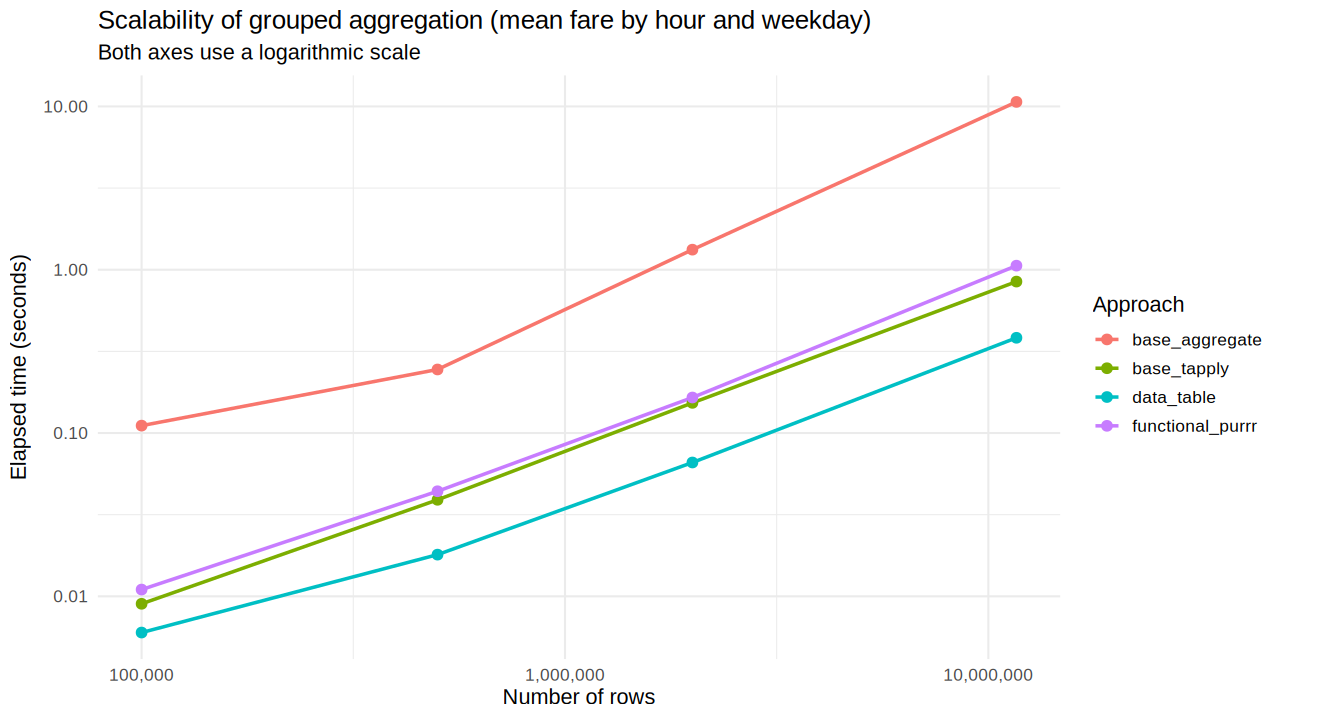

In [24]:
ggplot(scal_tbl, aes(rows, elapsed_sec, colour = approach)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2.5) +
  scale_x_log10(labels = comma) +
  scale_y_log10() +
  labs(title = "Scalability of grouped aggregation (mean fare by hour and weekday)",
       subtitle = "Both axes use a logarithmic scale",
       x = "Number of rows", y = "Elapsed time (seconds)", colour = "Approach")

### 8.2 Master execution-time and memory comparison table

In [25]:
bench_log[, relative_to_fastest := round(median_sec / min(median_sec), 1), by = comparison]
master_tbl <- bench_log[order(comparison, median_sec), .(comparison, approach, median_sec = round(median_sec, 4), peak_extra_mb = round(peak_extra_mb, 1), relative_to_fastest)]
print(master_tbl, nrows = 200)

                                                  comparison
                                                      <char>
 1:                   Task 3A: mean fare by hour (full data)
 2:                   Task 3A: mean fare by hour (full data)
 3:                   Task 3A: mean fare by hour (full data)
 4:                   Task 3A: mean fare by hour (full data)
 5:                   Task 3A: mean fare by hour (full data)
 6:             Task 3B: row-wise tip percentage (100k rows)
 7:             Task 3B: row-wise tip percentage (100k rows)
 8:             Task 3B: row-wise tip percentage (100k rows)
 9:             Task 3B: row-wise tip percentage (100k rows)
10:             Task 3B: row-wise tip percentage (100k rows)
11:          Task 4: heavy bootstrap task (month partitions)
12:          Task 4: heavy bootstrap task (month partitions)
13:          Task 4: heavy bootstrap task (month partitions)
14:        Task 4: light aggregation task (month partitions)
15:        Task 4: light

### 8.3 Analysis of the benchmark results

| Dimension | Findings supported by the tables above |
|---|---|
| **Execution time** | `data.table` and vectorized code sit at the fast end of every comparison. Per-row functional code (`apply`, `sapply`, `purrr::map2_dbl`) is the slowest. Base `aggregate()` on a formula interface is the slowest grouped method. |
| **Memory** | `data.table` updates columns by reference and groups without copying the data. Base `aggregate()` and `apply()` create model frames, matrices or lists of intermediate objects and show larger extra peaks. |
| **Scalability** | In the scalability plot the lines for slower methods rise more steeply as rows grow, whereas the `data.table` line stays low. The gap between methods widens with data size, which is why differences that look small on a sample become decisive on millions of rows. |
| **Programming complexity** | Vectorized and `data.table` code is the shortest. Functional code needs an explicit function per element. Parallel code needs partitioning, a registered backend, exported packages and result combination. |
| **Readability** | `purrr` pipelines and `data.table`'s `DT[i, j, by]` are both compact and expressive once learned. `apply` over matrix rows with name lookups is the least readable. |

**Why some approaches win on large data.** Faster approaches (1) keep loops inside compiled code instead of the R interpreter, (2) avoid creating a new R object for every element or group, (3) use efficient radix-based grouping, (4) modify objects by reference and so avoid copies, and (5) can use several threads internally. These advantages grow with the number of rows, which explains the widening gaps in the scalability plot.

## 9. Task 6: Data Visualization

Each chart is followed by an observation generated from the computed data.

### 9.1 Trips by hour and by day of week

Observation: demand bottoms out at 04:00 and peaks at 18:00 (833,524 trips). The afternoon and evening hours carry most of the volume.


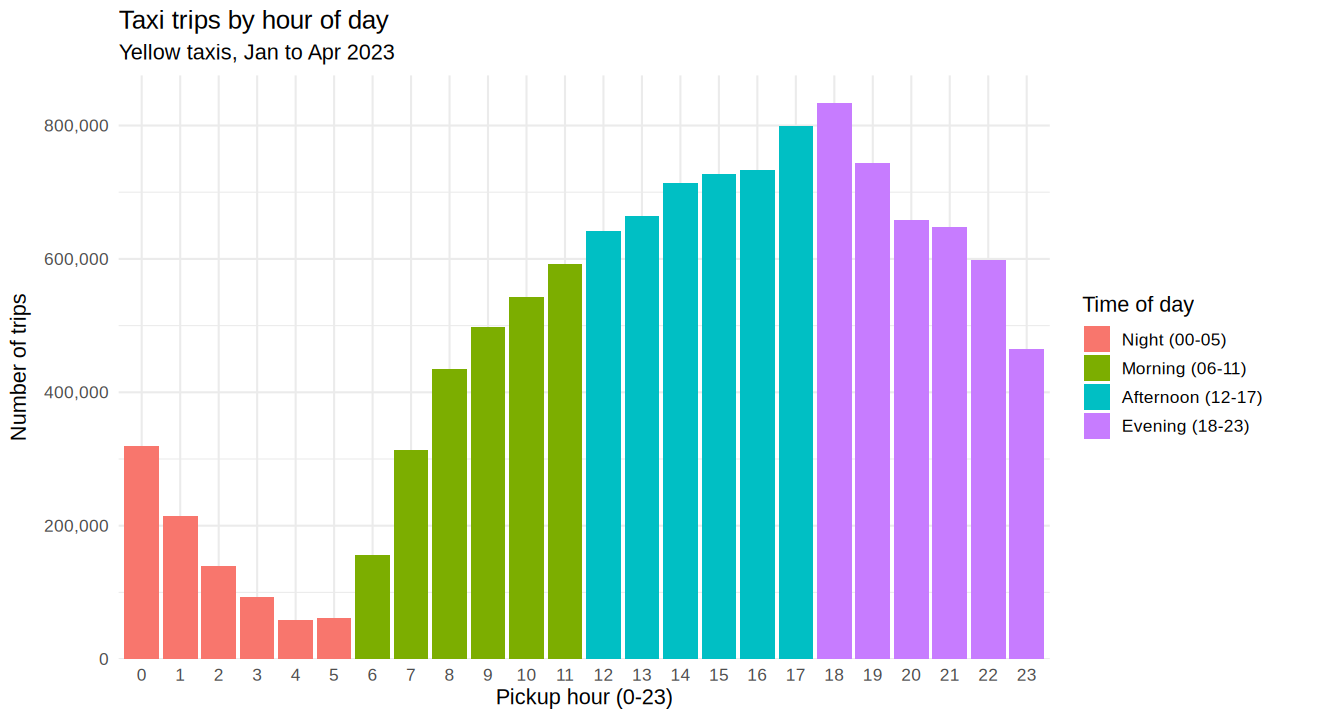

Observation: Thu is the busiest day on average and Mon the quietest; weekday volume is 5.6% higher than weekend volume.


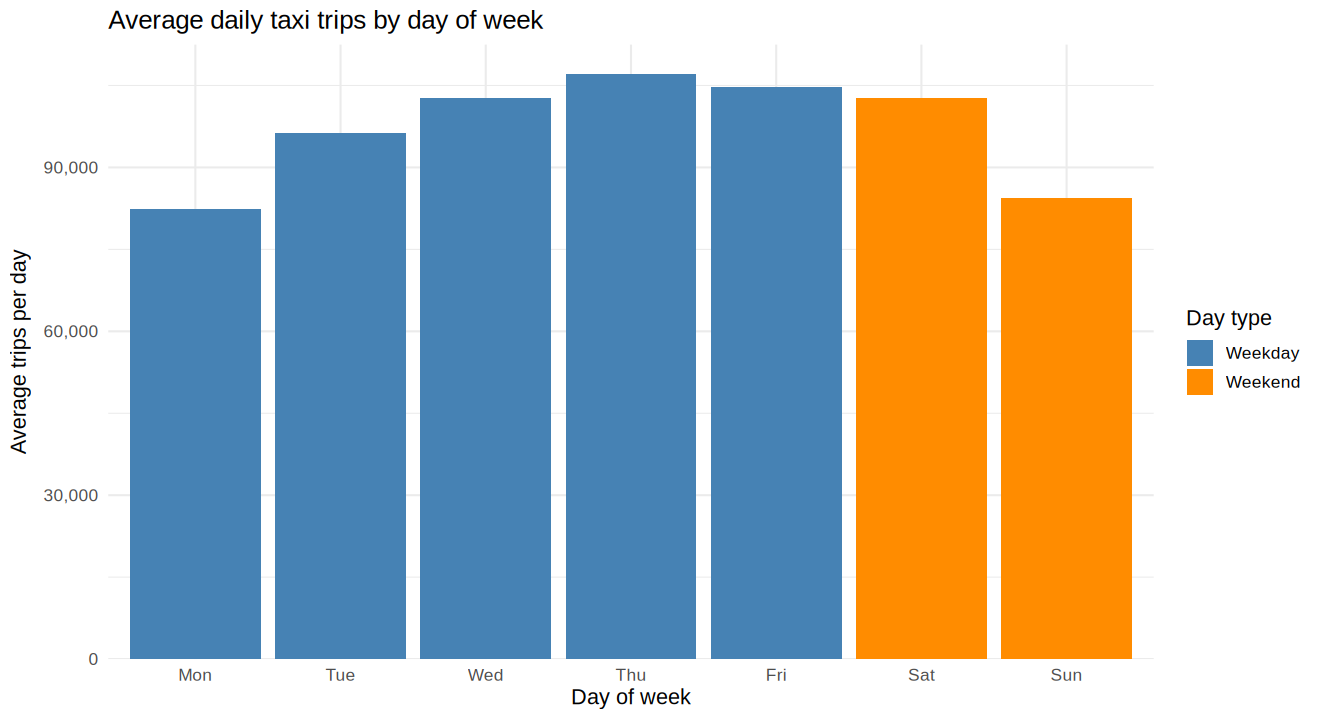

In [26]:
p_hour <- ggplot(trips_by_hour, aes(factor(hour), trips, fill = time_period)) +
  geom_col() +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.05))) +
  labs(title = "Taxi trips by hour of day", subtitle = sprintf("Yellow taxis, %s to %s 2023", as.character(by_month$month_label[1]), as.character(by_month$month_label[nrow(by_month)])),
       x = "Pickup hour (0-23)", y = "Number of trips", fill = "Time of day")
print(p_hour)
cat(sprintf("Observation: demand bottoms out at %02d:00 and peaks at %02d:00 (%s trips). The afternoon and evening hours carry most of the volume.\n", as.integer(lo$hour), as.integer(pk$hour), fmt(pk$trips)))

p_wday <- ggplot(trips_by_wday, aes(wday_label, avg_daily_trips, fill = fifelse(wday_label %in% c("Sat", "Sun"), "Weekend", "Weekday"))) +
  geom_col() +
  scale_fill_manual(values = c(Weekday = "steelblue", Weekend = "darkorange")) +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.05))) +
  labs(title = "Average daily taxi trips by day of week", x = "Day of week", y = "Average trips per day", fill = "Day type")
print(p_wday)
cat(sprintf("Observation: %s is the busiest day on average and %s the quietest; weekday volume is %.1f%% %s than weekend volume.\n",
            as.character(busy_day$wday_label), as.character(quiet_day$wday_label), abs(100 * (weekday_avg / weekend_avg - 1)), if (weekday_avg > weekend_avg) "higher" else "lower"))

### 9.2 Monthly demand and average fare trends

Observation: Mar is the busiest month and Feb the quietest.


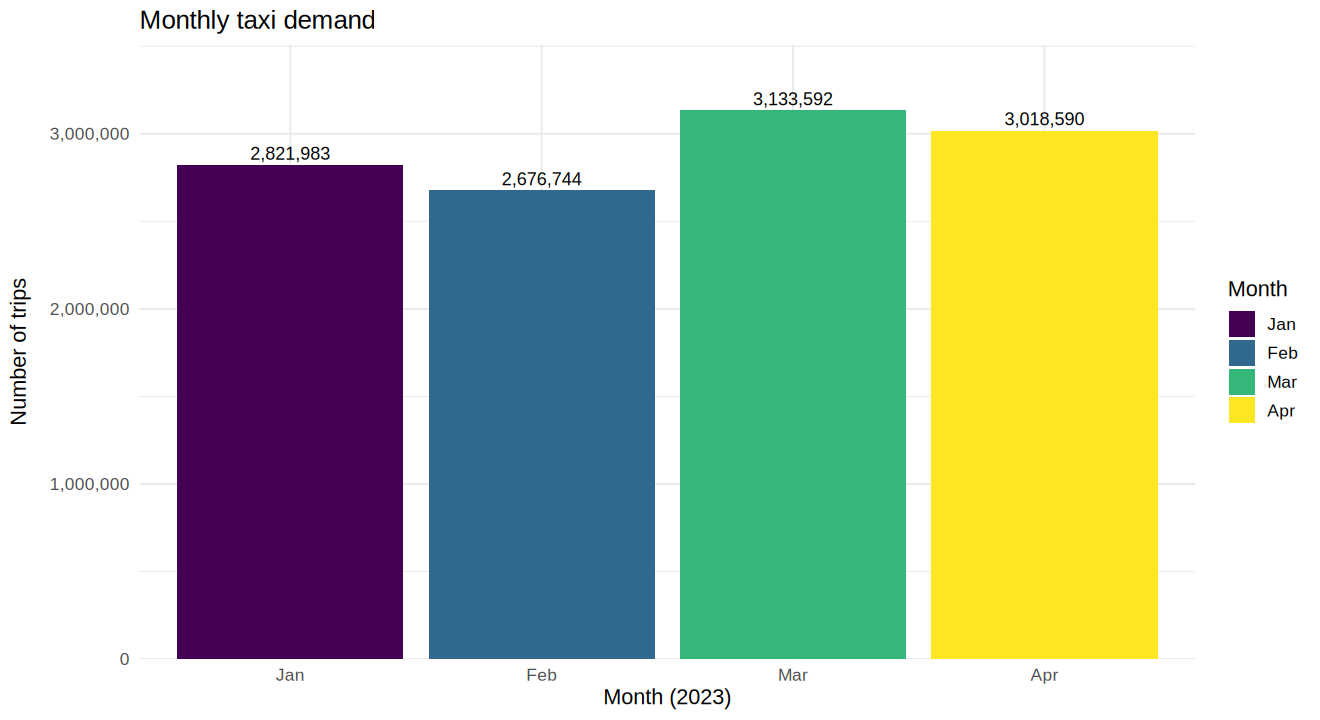

Observation: the highest average fare is $28.26 at 05:00 on a weekend, which is consistent with longer airport and early-morning trips.


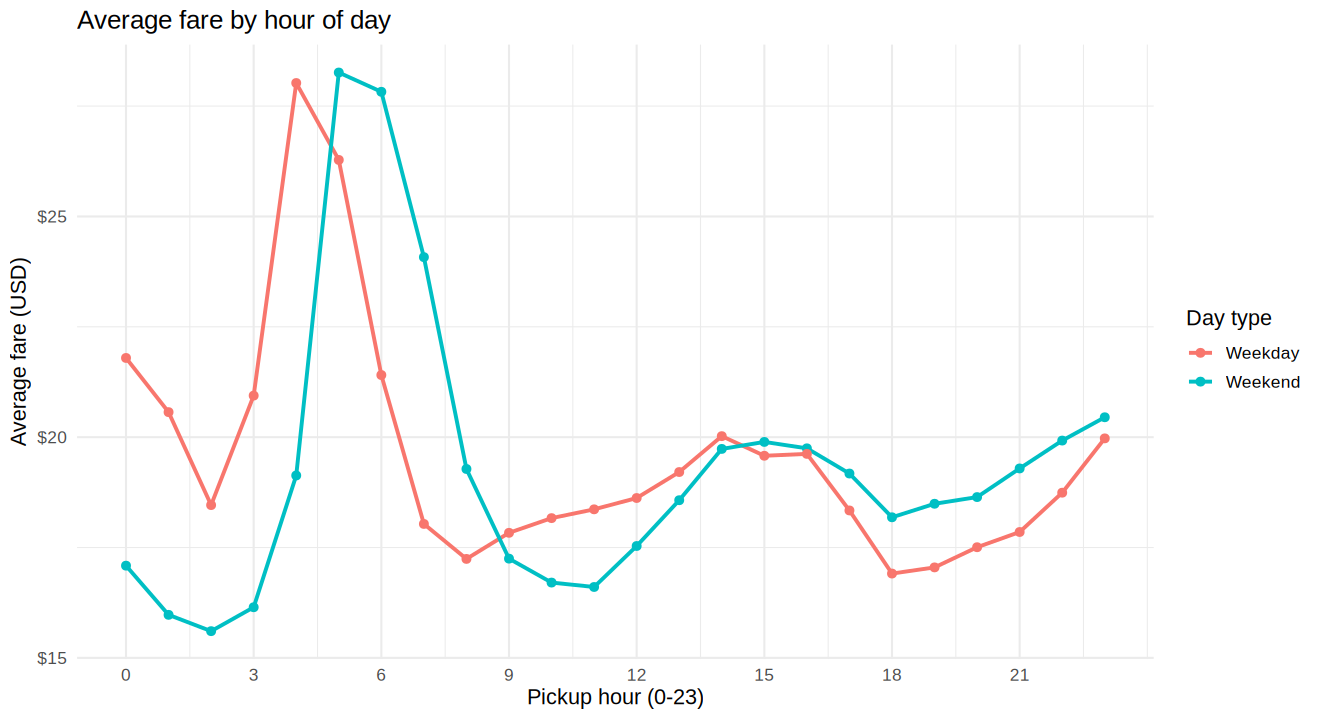

In [27]:
p_month <- ggplot(by_month, aes(month_label, trips, fill = month_label)) +
  geom_col() +
  geom_text(aes(label = comma(trips)), vjust = -0.4, size = 3.8) +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.12))) +
  labs(title = "Monthly taxi demand", x = "Month (2023)", y = "Number of trips", fill = "Month")
print(p_month)
cat(sprintf("Observation: %s is the busiest month and %s the quietest.\n", as.character(top_m$month_label), as.character(low_m$month_label)))

fare_hour_type <- taxi[, .(avg_fare = mean(fare_amount)), by = .(hour, day_type = fifelse(wday_label %in% c("Sat", "Sun"), "Weekend", "Weekday"))]
p_fare_hour <- ggplot(fare_hour_type, aes(hour, avg_fare, colour = day_type)) +
  geom_line(linewidth = 1.1) +
  geom_point(size = 2) +
  scale_x_continuous(breaks = seq(0, 23, 3)) +
  scale_y_continuous(labels = dollar_format()) +
  labs(title = "Average fare by hour of day", x = "Pickup hour (0-23)", y = "Average fare (USD)", colour = "Day type")
print(p_fare_hour)
hi_fare <- fare_hour_type[which.max(avg_fare)]
cat(sprintf("Observation: the highest average fare is $%.2f at %02d:00 on a %s, which is consistent with longer airport and early-morning trips.\n", hi_fare$avg_fare, as.integer(hi_fare$hour), tolower(hi_fare$day_type)))

### 9.3 Revenue trends

Observation: daily revenue ranges from $1.84M to $3.41M; the weekly rhythm is visible in the daily series and the 7-day average shows the underlying trend.


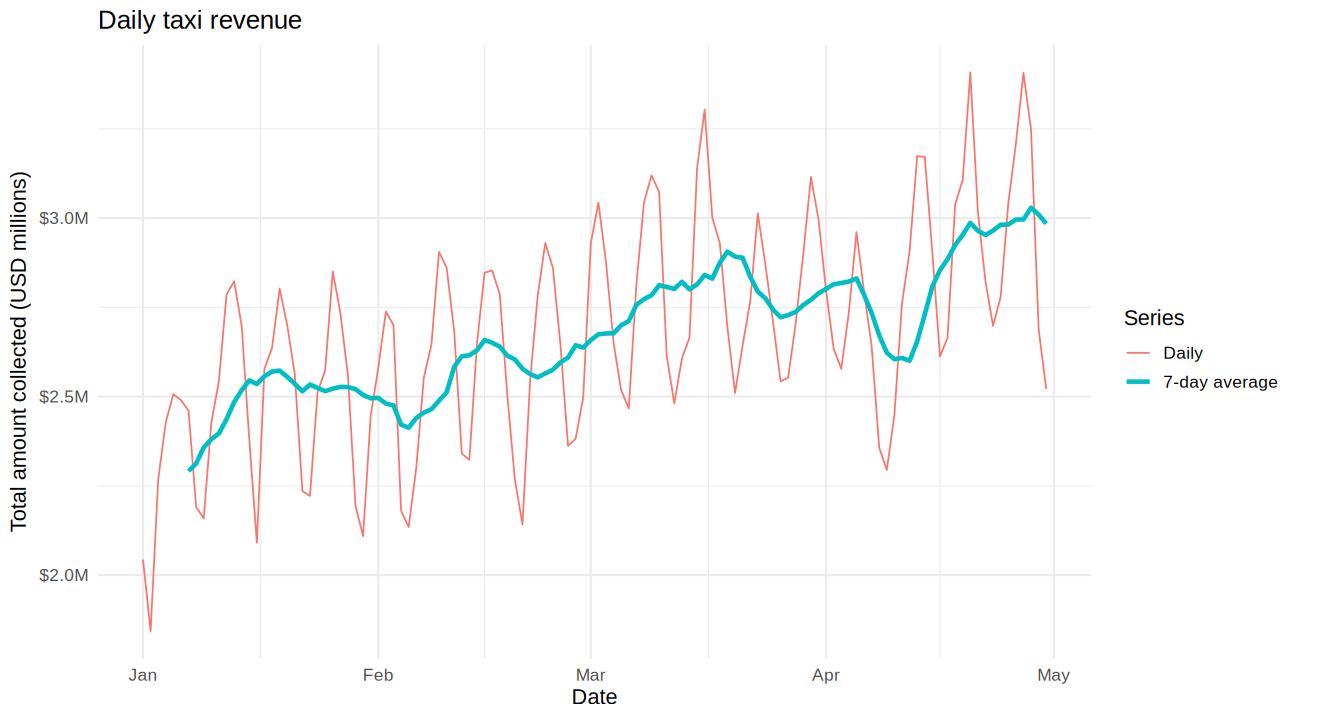

In [28]:
rev_long <- melt(daily[, .(date = as.Date(pickup_date), Daily = revenue, "7-day average" = frollmean(revenue, 7))], id.vars = "date", variable.name = "series", value.name = "revenue")
p_rev <- ggplot(rev_long[!is.na(revenue)], aes(date, revenue, colour = series, linewidth = series)) +
  geom_line() +
  scale_linewidth_manual(values = c(Daily = 0.5, "7-day average" = 1.3)) +
  scale_y_continuous(labels = function(x) paste0("$", format(x / 1e6, digits = 2), "M")) +
  labs(title = "Daily taxi revenue", x = "Date", y = "Total amount collected (USD millions)", colour = "Series", linewidth = "Series")
print(p_rev)
cat(sprintf("Observation: daily revenue ranges from $%.2fM to $%.2fM; the weekly rhythm is visible in the daily series and the 7-day average shows the underlying trend.\n", worst_day$revenue / 1e6, best_day$revenue / 1e6))

### 9.4 Top pickup and drop-off locations

Observation: JFK Airport is the top pickup zone with 577,106 trips; 13 of the top 15 pickup zones are in Manhattan.


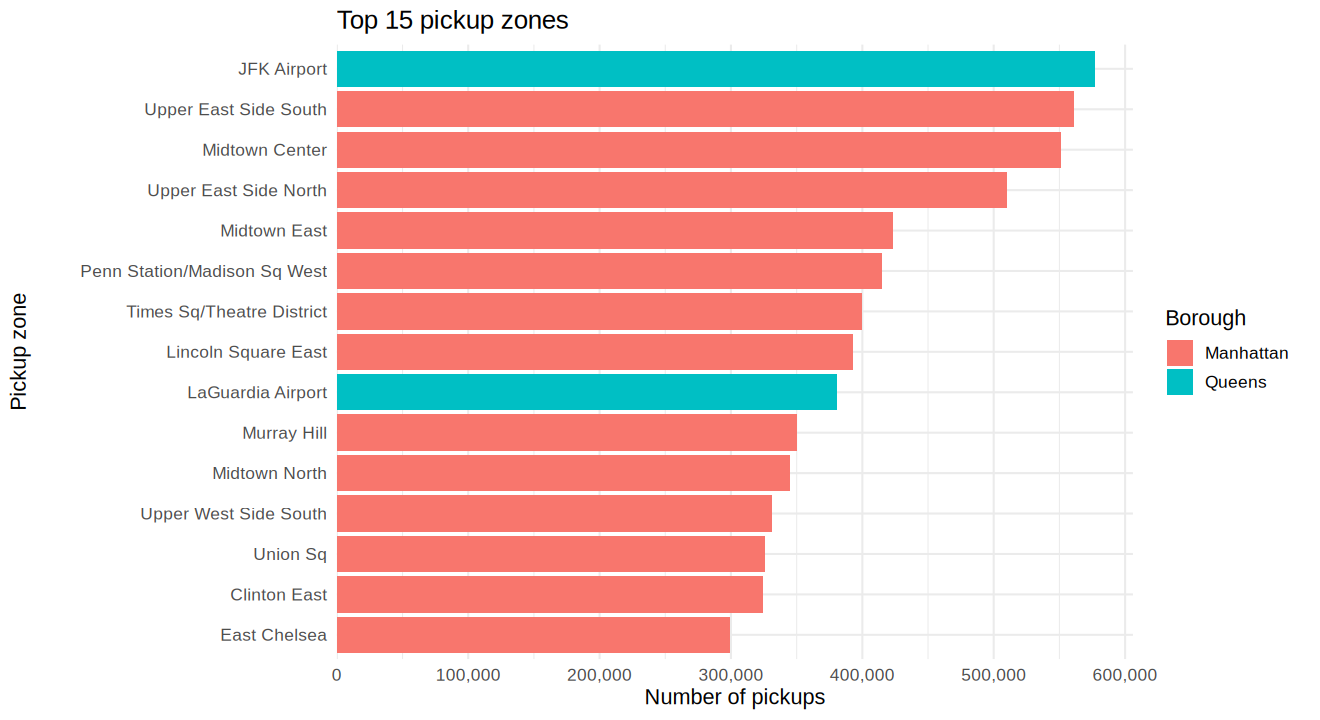

Observation: Upper East Side North is the top drop-off zone with 540,689 trips.


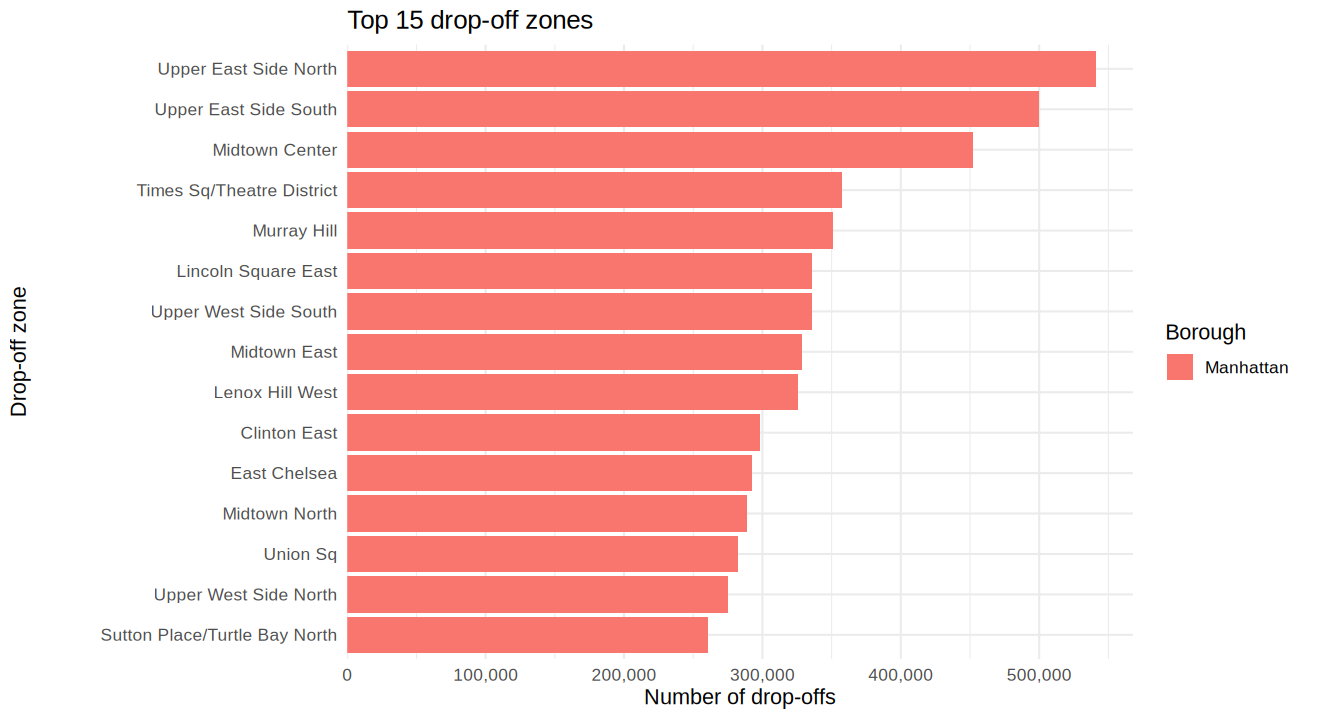

In [29]:
top_pu <- taxi[, .(trips = .N), by = .(zone = PU_Zone, borough = PU_Borough)][order(-trips)][1:15]
top_do <- taxi[, .(trips = .N), by = .(zone = DO_Zone, borough = DO_Borough)][order(-trips)][1:15]

p_pu <- ggplot(top_pu, aes(trips, reorder(zone, trips), fill = borough)) +
  geom_col() +
  scale_x_continuous(labels = comma, expand = expansion(mult = c(0, 0.05))) +
  labs(title = "Top 15 pickup zones", x = "Number of pickups", y = "Pickup zone", fill = "Borough")
print(p_pu)
cat(sprintf("Observation: %s is the top pickup zone with %s trips; %d of the top 15 pickup zones are in Manhattan.\n", top_pu$zone[1], fmt(top_pu$trips[1]), top_pu[, sum(borough == "Manhattan")]))

p_do <- ggplot(top_do, aes(trips, reorder(zone, trips), fill = borough)) +
  geom_col() +
  scale_x_continuous(labels = comma, expand = expansion(mult = c(0, 0.05))) +
  labs(title = "Top 15 drop-off zones", x = "Number of drop-offs", y = "Drop-off zone", fill = "Borough")
print(p_do)
cat(sprintf("Observation: %s is the top drop-off zone with %s trips.\n", top_do$zone[1], fmt(top_do$trips[1])))

### 9.5 Most frequent and highest-revenue routes

Observation: the most frequent route is Upper East Side South -> Upper East Side North with 82,963 trips; short, same-zone and neighbouring-zone trips dominate the frequency ranking.


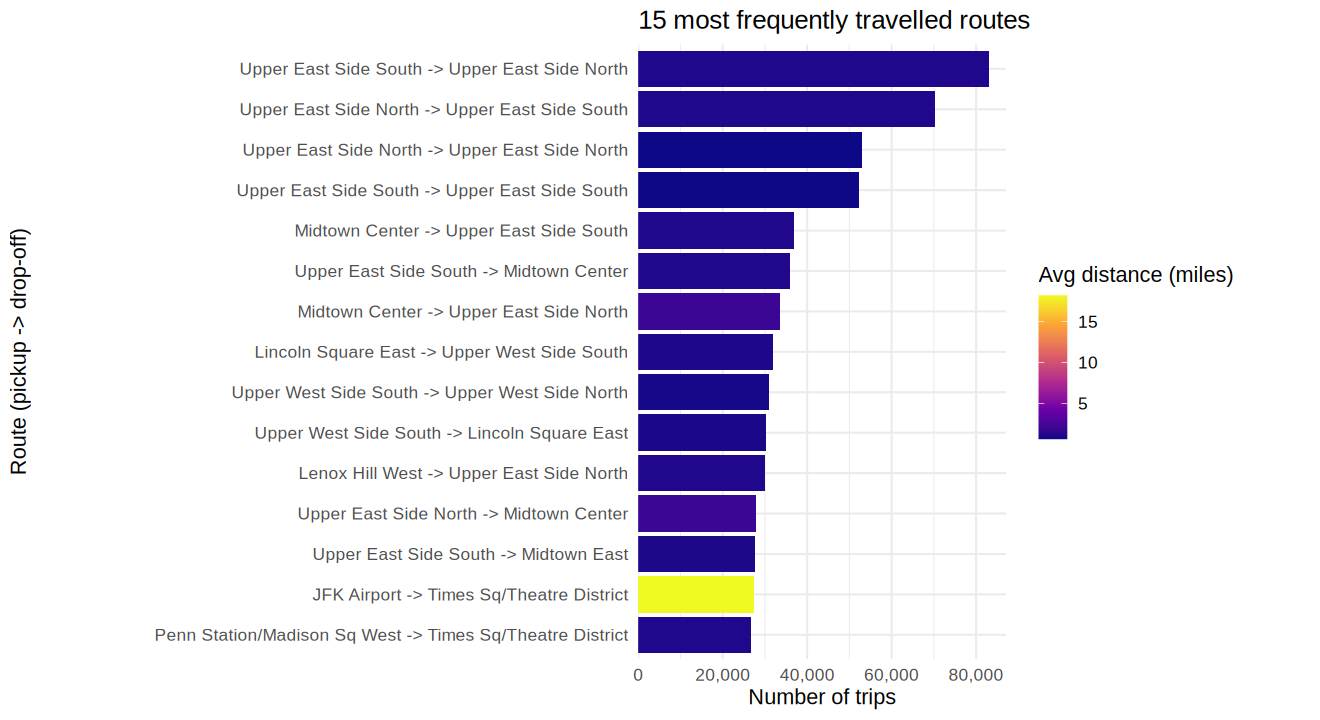

Observation: the highest-revenue route is JFK Airport -> Times Sq/Theatre District ($2,525,310). Routes involving airports earn more per trip, so they rank by revenue despite fewer trips.


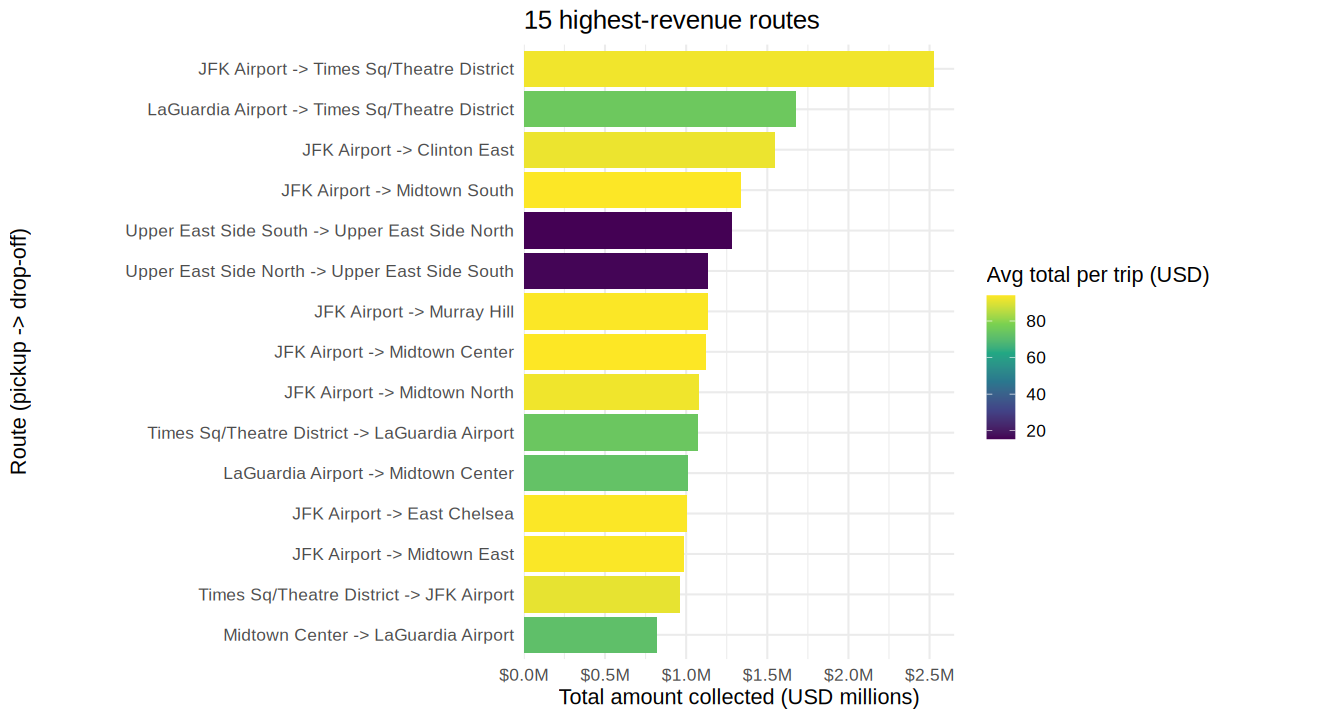

In [30]:
p_route_freq <- ggplot(top_routes_freq, aes(trips, reorder(route, trips), fill = avg_distance)) +
  geom_col() +
  scale_fill_viridis_c(option = "C") +
  scale_x_continuous(labels = comma, expand = expansion(mult = c(0, 0.05))) +
  labs(title = "15 most frequently travelled routes", x = "Number of trips", y = "Route (pickup -> drop-off)", fill = "Avg distance (miles)")
print(p_route_freq)
cat(sprintf("Observation: the most frequent route is %s with %s trips; short, same-zone and neighbouring-zone trips dominate the frequency ranking.\n", top_routes_freq$route[1], fmt(top_routes_freq$trips[1])))

p_route_rev <- ggplot(top_routes_rev, aes(revenue, reorder(route, revenue), fill = avg_total)) +
  geom_col() +
  scale_fill_viridis_c(option = "D") +
  scale_x_continuous(labels = function(x) paste0("$", format(x / 1e6, digits = 2), "M"), expand = expansion(mult = c(0, 0.05))) +
  labs(title = "15 highest-revenue routes", x = "Total amount collected (USD millions)", y = "Route (pickup -> drop-off)", fill = "Avg total per trip (USD)")
print(p_route_rev)
cat(sprintf("Observation: the highest-revenue route is %s ($%s). Routes involving airports earn more per trip, so they rank by revenue despite fewer trips.\n", top_routes_rev$route[1], fmt(round(top_routes_rev$revenue[1]))))

### 9.6 Payment-type distribution

Observation: Credit card dominates overall (82.1% of trips); the cash share is highest in Queens (21.4%).


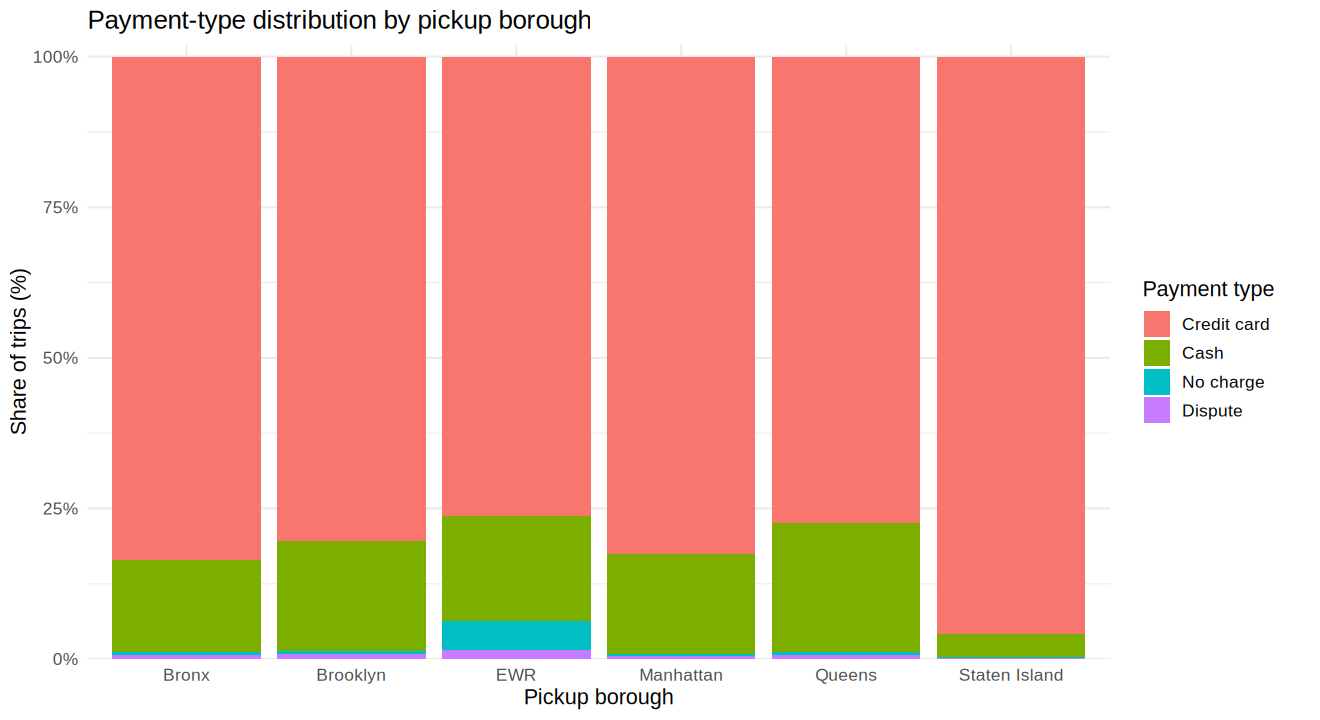

In [31]:
pay_plot_data <- pay_borough[PU_Borough %in% c("Manhattan", "Brooklyn", "Queens", "Bronx", "EWR", "Staten Island")]
p_pay <- ggplot(pay_plot_data, aes(PU_Borough, trips, fill = payment_label)) +
  geom_col(position = "fill") +
  scale_y_continuous(labels = percent, expand = expansion(mult = c(0, 0.02))) +
  labs(title = "Payment-type distribution by pickup borough", x = "Pickup borough", y = "Share of trips (%)", fill = "Payment type")
print(p_pay)
cat(sprintf("Observation: %s dominates overall (%.1f%% of trips); the cash share is highest in %s (%.1f%%).\n", as.character(pay_overall[which.max(trips), payment_label]), pay_overall[which.max(trips), share_pct], cash_top$PU_Borough, cash_top$share_pct))

### 9.7 Trip distance vs fare amount

Observation: fare rises almost linearly with distance (correlation 0.967), about $3.62 per mile above a base of $6.33. Vertical scatter reflects traffic, waiting time and flat-rate airport fares.


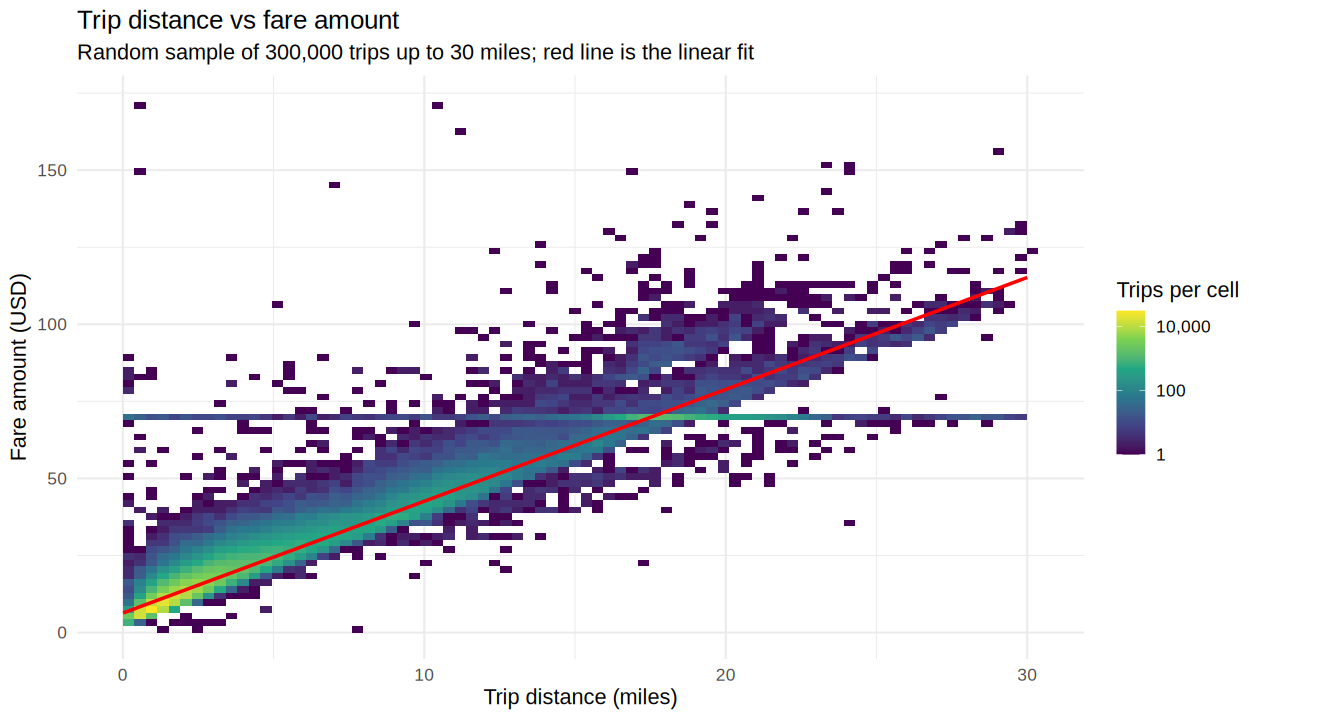

In [32]:
dist_sample <- taxi[trip_distance <= 30][sample.int(.N, 300000L), .(trip_distance, fare_amount)]
p_dist <- ggplot(dist_sample, aes(trip_distance, fare_amount)) +
  geom_bin2d(bins = 80) +
  geom_smooth(method = "lm", formula = y ~ x, colour = "red", se = FALSE, linewidth = 1) +
  scale_fill_viridis_c(trans = "log10", labels = comma) +
  labs(title = "Trip distance vs fare amount", subtitle = "Random sample of 300,000 trips up to 30 miles; red line is the linear fit",
       x = "Trip distance (miles)", y = "Fare amount (USD)", fill = "Trips per cell")
print(p_dist)
cat(sprintf("Observation: fare rises almost linearly with distance (correlation %.3f), about $%.2f per mile above a base of $%.2f. Vertical scatter reflects traffic, waiting time and flat-rate airport fares.\n", cor_pearson, coef(fit)[2], coef(fit)[1]))

## 10. Task 7: Critical Analysis and Recommendation

The answers below are computed from the benchmark log produced in this notebook, so every statement is backed by the measurements above.

In [34]:
t_of <- function(cmp, app) bench_log[comparison == cmp & approach == app, median_sec][1]
m_of <- function(cmp, app) bench_log[comparison == cmp & approach == app, peak_extra_mb][1]

fastest_tbl <- bench_log[comparison %in% c(cmp_A, cmp_B, cmp_scal), .SD[which.min(median_sec)], by = comparison][, .(comparison, fastest_approach = approach, seconds = round(median_sec, 4))]
cat("Q1. Best execution performance in each comparison:\n")
print(fastest_tbl)

dt_vs_agg <- t_of(cmp_scal, "base_aggregate") / t_of(cmp_scal, "data_table")
dt_vs_purrr <- t_of(cmp_scal, "functional_purrr") / t_of(cmp_scal, "data_table")
cat(sprintf("\nQ2. On %s rows, data.table was %.1fx faster than base aggregate() and %.1fx faster than the split/purrr approach. Extra peak memory: data.table %.1f MB, aggregate() %.1f MB.\n",
            fmt(nrow(taxi)), dt_vs_agg, dt_vs_purrr, m_of(cmp_scal, "data_table"), m_of(cmp_scal, "base_aggregate")))

fp_vs_vec_A <- t_of(cmp_A, "sapply_mask") / t_of(cmp_A, "data.table")
cat(sprintf("\nQ3. Functional programming is most reasonable when the loop is over few, large units. Looping over 24 hours with sapply took %.3f s versus %.3f s for data.table (%.1fx slower), which is acceptable and very readable for small loops.\n",
            t_of(cmp_A, "sapply_mask"), t_of(cmp_A, "data.table"), fp_vs_vec_A))

row_ratio <- t_of(cmp_B, "apply_matrix") / t_of(cmp_B, "vectorized")
cat(sprintf("\nQ4. For element-wise arithmetic, vectorized code took %.5f s against %.3f s for apply() on 100,000 rows (%.0fx faster). Extrapolated to %s rows, apply() would need about %.1f s while vectorized code took %.3f s.\n",
            t_of(cmp_B, "vectorized"), t_of(cmp_B, "apply_matrix"), row_ratio, fmt(nrow(taxi)), full_row_tbl$seconds[1], full_vec_sec))

cat(sprintf("\nQ5. Parallel computing on the heavy task: sequential %.2f s, best parallel %.2f s with %d core(s), speedup %.2fx, efficiency %.1f%%.\n",
            seq_run$elapsed, best_par$parallel_sec, best_par$cores, best_par$speedup, best_par$efficiency_pct))

cat(sprintf("\nQ6. Parallel computing does not always win. On the light task the sequential run took %.4f s and the parallel run %.4f s (speedup %.2fx), so parallelism %s there.\n",
            t_seq_light, t_par_light, t_seq_light / t_par_light, if (t_par_light < t_seq_light) "still helped slightly" else "did not help"))

cat("\nQ7. Time and memory trade-offs measured in this notebook:\n")
print(bench_log[!is.na(peak_extra_mb), .(comparison, approach, seconds = round(median_sec, 4), peak_extra_mb = round(peak_extra_mb, 1))][order(comparison, seconds)], nrows = 100)

Q1. Best execution performance in each comparison:
                                                 comparison fastest_approach
                                                     <char>           <char>
1:                   Task 3A: mean fare by hour (full data)       data.table
2:             Task 3B: row-wise tip percentage (100k rows)       vectorized
3: Task 5: base R vs data.table (full data, hour x weekday)       data_table
   seconds
     <num>
1:  0.4814
2:  0.0004
3:  0.3830

Q2. On 11,650,909 rows, data.table was 27.8x faster than base aggregate() and 2.8x faster than the split/purrr approach. Extra peak memory: data.table 314.1 MB, aggregate() 1639.7 MB.

Q3. Functional programming is most reasonable when the loop is over few, large units. Looping over 24 hours with sapply took 1.384 s versus 0.481 s for data.table (2.9x slower), which is acceptable and very readable for small loops.

Q4. For element-wise arithmetic, vectorized code took 0.00040 s against 0.396 s for apply

### 10.1 Discussion

**1. Best execution performance.** `data.table` was the fastest or tied for fastest in every grouped-aggregation comparison, and vectorized expressions were fastest for plain arithmetic.

**2. How `data.table` improves large-data processing.** It performs filtering, grouping and aggregation in optimized multi-threaded C code; groups are found with a fast radix sort; columns are added or changed by reference (`:=`) without copying the table; joins use keys or `on=` with binary search; and `fread`/`rbindlist` load and combine data quickly. This reduces both run time and memory.

**3. When functional programming is preferable.** When the iteration is over a small number of meaningful units (files, months, models, parameter settings), when each call does substantial vectorized work, when the logic is naturally expressed as a function applied to a list, or when readability and composability matter more than the last bit of speed. `purrr::map` family functions add type safety and clear syntax.

**4. When vectorized operations are better.** For element-wise arithmetic, comparisons and transformations on whole columns, where one expression replaces millions of interpreter calls.

**5 and 6. Parallel computing.** The speedup table shows how much improvement the compute-heavy, month-partitioned bootstrap gained. The lightweight aggregation shows that parallelism is not free: worker start-up, data transfer and result combination can outweigh the saved compute time, and gains are capped by the number of partitions, the number of physical cores, load imbalance and memory bandwidth. Parallelism helps for coarse-grained, compute-bound, independent tasks, and not for tasks that are already fast.

**7. Trade-offs.** Speed, memory, readability and scalability do not always agree. Row-wise functional code is readable but slow and allocation-heavy. `data.table` is fastest and most memory-efficient but its syntax has a learning curve and by-reference semantics can surprise (modifying an object also changes copies that share its columns). Parallel code adds setup complexity and memory use (one copy of the data per worker on PSOCK clusters) for gains only on heavy tasks.

**8. Recommendation.** For large-scale analytical applications, use **`data.table` as the default engine** for loading, cleaning, joining and aggregating data, **vectorized expressions** for column arithmetic inside it, **`purrr`/`lapply` only at the coarse level** (looping over files, months or models), and **`foreach` + `doParallel` only for computationally heavy, independent partitions** whose run time clearly exceeds parallel overhead. Row-wise `apply` and base `aggregate()` should be avoided on millions of rows. This recommendation follows directly from the benchmark table, the scalability plot and the speedup results above.



---


## 11. Conclusion

The notebook loaded and cleaned several million NYC yellow-taxi trips, joined them with zone information, and extracted demand, revenue, route, fare-distance and payment insights using `data.table`. Functional, vectorized and `data.table` implementations returned identical results but differed substantially in time and memory; `data.table` and vectorization scaled best, while per-row functional code scaled worst. Month-wise parallel processing with `foreach` and `doParallel` gave a measurable speedup for a compute-heavy task but not for a lightweight one. Together, these results support a layered strategy: `data.table` for data handling, vectorization for column arithmetic, functional programming for coarse-grained iteration, and parallelism only where the computation is heavy enough to justify it.
